In [5]:
##################################TRANSFORMAÇÃO DE DADOS#####################################

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


# =========================
# 0) FUNÇÕES
# =========================

def limpar_kwh(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = (
                df[c].astype(str)
                .str.replace(',', '.', regex=False)
                .replace('nan', np.nan)
                .astype(float)
            )
    return df

def get_time_segment(h):
    if 6 <= h < 11:
        return 'morning'
    elif 11 <= h < 15:
        return 'lunch'
    elif 15 <= h < 19:
        return 'afternoon'
    else:
        return 'night'

def add_time_features(df):
    df = df.copy()
    df['weekday'] = df['timestamp'].dt.weekday
    df['month'] = df['timestamp'].dt.month
    df['hour'] = df['timestamp'].dt.hour

    fixed_holidays = {
        (1, 1), (4, 25), (5, 1), (6, 10),
        (8, 15), (10, 5), (11, 1),
        (12, 1), (12, 8), (12, 25)
    }
    df['is_holiday'] = df['timestamp'].apply(
        lambda x: 1 if (x.month, x.day) in fixed_holidays else 0
    ).astype(int)

    df['time_segment'] = df['hour'].apply(get_time_segment)
    df['month_segment'] = df['month'].astype(str) + '_' + df['time_segment']

    # cíclicas
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

def imputar_meteo_melhor(meteo):
    meteo = meteo.copy().sort_values('timestamp')

    meteo_cols = [
        'temp', 'feels_like', 'temp_min', 'temp_max',
        'pressure', 'humidity', 'wind_speed', 'rain_1h',
        'clouds_all'
    ]
    for col in meteo_cols:
        meteo[col] = pd.to_numeric(meteo[col], errors='coerce')

    # interpolação temporal
    meteo = meteo.set_index('timestamp')
    meteo[meteo_cols] = meteo[meteo_cols].interpolate(method='time', limit_direction='both')
    meteo = meteo.reset_index()

    # fallback por (mês, hora)
    meteo['month'] = meteo['timestamp'].dt.month
    meteo['hour'] = meteo['timestamp'].dt.hour

    for col in meteo_cols:
        grp_med = meteo.groupby(['month', 'hour'])[col].transform('median')
        meteo[col] = meteo[col].fillna(grp_med)
        meteo[col] = meteo[col].fillna(meteo[col].median())

    meteo['rain_1h'] = meteo['rain_1h'].fillna(0)

    # garantir coluna + strings
    if 'weather_description' in meteo.columns:
        meteo['weather_description'] = meteo['weather_description'].fillna('missing').astype(str)
    else:
        meteo['weather_description'] = 'missing'

    return meteo

def make_model1_mlp(n_features, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# =========================
# 1) LOAD TREINO (2021-2022)
# =========================

TARGET = 'Injeção na rede (kWh)'
kwh_cols = ['Normal (kWh)', 'Horário Económico (kWh)', 'Autoconsumo (kWh)']

energia = pd.concat([
    pd.read_csv('energia_202109-202112.csv', encoding='latin1'),
    pd.read_csv('energia_202201-202212.csv', encoding='latin1'),
], ignore_index=True)

meteo = pd.concat([
    pd.read_csv('meteo_202109-202112.csv', encoding='latin1'),
    pd.read_csv('meteo_202201-202212.csv', encoding='latin1'),
], ignore_index=True)

energia['timestamp'] = pd.to_datetime(energia['Data']) + pd.to_timedelta(energia['Hora'], unit='h')

meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(r' \+0000 UTC', '', regex=True)
meteo['timestamp'] = pd.to_datetime(meteo['dt_iso_clean'])

energia = limpar_kwh(energia, kwh_cols)
meteo = imputar_meteo_melhor(meteo)

meteo_keep = [
    'timestamp', 'temp', 'feels_like', 'temp_min', 'temp_max',
    'pressure', 'humidity', 'wind_speed', 'rain_1h',
    'clouds_all', 'weather_description'
]
df = pd.merge(energia, meteo[meteo_keep], on='timestamp', how='left')

# features temporais
df = add_time_features(df)

# target (5 classes)
df[TARGET] = df[TARGET].where(df[TARGET].notnull(), 'None').astype(str).replace({'Very High': 'Very_High'})

le_full = LabelEncoder()
df['y_full'] = le_full.fit_transform(df[TARGET])
print("Classes:", list(le_full.classes_))

# =========================
# 2) WEATHER ENCODER (MELHOR SOLUÇÃO: garantir 'missing' no FIT)
# =========================
df['weather_description'] = df['weather_description'].fillna('missing').astype(str)
uniq_weather = df['weather_description'].unique().tolist()
if 'missing' not in uniq_weather:
    uniq_weather.append('missing')

le_weather = LabelEncoder()
le_weather.fit(uniq_weather)

df['weather_encoded'] = le_weather.transform(df['weather_description'])

# dummies categóricas temporais
df = pd.get_dummies(
    df,
    columns=['weekday', 'month', 'time_segment', 'month_segment', 'is_holiday'],
    drop_first=False
)

# =========================
# 3) NORMALIZAÇÃO CONTÍNUAS (fit no treino)
# =========================
continuous_cols = [
    'Normal (kWh)', 'Horário Económico (kWh)', 'Autoconsumo (kWh)',
    'temp', 'feels_like', 'temp_min', 'temp_max',
    'pressure', 'humidity', 'wind_speed', 'rain_1h', 'clouds_all',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

# =========================
# 4) FEATURES FINAIS (fixas)
# =========================
exclude_cols = {
    TARGET, 'y_full', 'timestamp', 'Data', 'Hora', 'dt_iso', 'dt_iso_clean', 'weather_description'
}
feature_cols = [c for c in df.columns if c not in exclude_cols]

# ordenar temporalmente e construir matrizes
df = df.sort_values('timestamp')
X_all = df[feature_cols].to_numpy(dtype='float32')
y_full = df['y_full'].to_numpy(dtype='int32')

# split temporal 80/20 para validação
cut = int(len(df) * 0.8)
X_train, X_val = X_all[:cut], X_all[cut:]
y_train_full, y_val_full = y_full[:cut], y_full[cut:]



Classes: ['High', 'Low', 'Medium', 'None', 'Very_High']


Epoch 1/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7747 - loss: 0.6056 - val_accuracy: 0.8834 - val_loss: 0.3236
Epoch 2/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.8306 - loss: 0.4336 - val_accuracy: 0.8838 - val_loss: 0.3031
Epoch 3/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - accuracy: 0.8443 - loss: 0.3932 - val_accuracy: 0.8852 - val_loss: 0.2938
Epoch 4/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8532 - loss: 0.3713 - val_accuracy: 0.8902 - val_loss: 0.2885
Epoch 5/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8583 - loss: 0.3562 - val_accuracy: 0.8902 - val_loss: 0.2839
Epoch 6/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.8625 - loss: 0.3443 - val_accuracy: 0.8920 - val_loss: 0.2813
Epoch 7/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - accuracy: 0.8645 - loss: 0.3346 - val_accuracy: 0.8929 - val_loss: 0.2796
Epoch 8/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.8677 - loss: 0.3264 - va

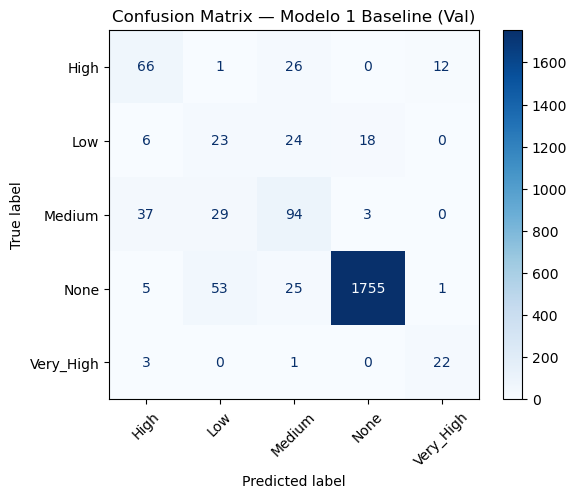

Epoch 1/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 474us/step - accuracy: 0.7540 - loss: 0.6765
Epoch 2/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.8450 - loss: 0.3988
Epoch 3/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.8554 - loss: 0.3608
Epoch 4/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - accuracy: 0.8623 - loss: 0.3412
Epoch 5/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step - accuracy: 0.8680 - loss: 0.3281
Epoch 6/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step - accuracy: 0.8719 - loss: 0.3179
Epoch 7/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.8746 - loss: 0.3097
Epoch 8/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.8758 - loss: 0.3028
Epoch 9/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.8794 - loss: 0.2967
Epoch 10/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.8817 - loss: 0.2913
Epoch 11/24
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.8825 - loss: 0.2865
Epoch 12/24
345/345 ━━━━━━━━━━

In [6]:

############################ MODELO 1 — MLP BASELINE #########################################
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)
model1 = make_model1_mlp(n_features=X_train.shape[1], n_classes=n_classes)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history1 = model1.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_val_pred = model1.predict(X_val, verbose=0).argmax(axis=1)
print("\n=== Classification Report (VAL) — Modelo 1 Baseline ===")
print(classification_report(y_val_full, y_val_pred, target_names=le_full.classes_))

cm = confusion_matrix(y_val_full, y_val_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_full.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — Modelo 1 Baseline (Val)")
plt.show()

best_epochs = len(history1.history['loss'])


# =========================
# 6) MODELO 1 FINAL — treinar em TODO o treino
# =========================
model1_final = make_model1_mlp(n_features=X_all.shape[1], n_classes=n_classes)
model1_final.fit(
    X_all, y_full,
    epochs=best_epochs,
    batch_size=32,
    verbose=1
)


# =========================
# 7) PREPARAR TESTE (2023) COM A MESMA TRANSFORMAÇÃO
# =========================
energia_test = pd.read_csv('energia_202301-202304.csv', encoding='latin1')
meteo_test   = pd.read_csv('meteo_202301-202304.csv', encoding='latin1')

energia_test['timestamp'] = pd.to_datetime(energia_test['Data']) + pd.to_timedelta(energia_test['Hora'], unit='h')

meteo_test['dt_iso_clean'] = meteo_test['dt_iso'].str.replace(r' \+0000 UTC', '', regex=True)
meteo_test['timestamp'] = pd.to_datetime(meteo_test['dt_iso_clean'])

energia_test = limpar_kwh(energia_test, kwh_cols)
meteo_test = imputar_meteo_melhor(meteo_test)

df_test = pd.merge(energia_test, meteo_test[meteo_keep], on='timestamp', how='left')
df_test = add_time_features(df_test)

# weather: garantir compatível com le_weather (melhor solução: 'missing' está no fit)
df_test['weather_description'] = df_test['weather_description'].fillna('missing').astype(str)
known = set(le_weather.classes_)
df_test.loc[~df_test['weather_description'].isin(known), 'weather_description'] = 'missing'
df_test['weather_encoded'] = le_weather.transform(df_test['weather_description'])

df_test = pd.get_dummies(
    df_test,
    columns=['weekday', 'month', 'time_segment', 'month_segment', 'is_holiday'],
    drop_first=False
)

# escalar contínuas com scaler do treino
df_test[continuous_cols] = scaler.transform(df_test[continuous_cols])

# alinhar colunas de features (garantir as 91 features do treino)
for c in feature_cols:
    if c not in df_test.columns:
        df_test[c] = 0
# e remover extras sem afetar (selecionamos só as do treino)
X_test = df_test[feature_cols].to_numpy(dtype='float32')

print("X_test:", X_test.shape)


# =========================
# 8) PREVER + GERAR SUBMISSÃO
# =========================
y_test_pred = model1_final.predict(X_test, verbose=0).argmax(axis=1)
labels_pred = le_full.inverse_transform(y_test_pred)

dummy = pd.read_csv('dummy_submission.csv')
assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"

dummy['Result'] = labels_pred
dummy.to_csv('submission_modelo1.csv', index=False)

print("Submissão pronta: submission_modelo1.csv")

O modelo é bom para o “caso médio”, mas fraco nos casos menos frequentes
Se uma classe tem pouco support, qualquer erro nela pesa muito no macro-F1
Quando não tem a certeza, prevê Medium ou None


Class weights: {0: 1.7659318637274548, 1: 4.881994459833795, 2: 1.8849197860962568, 3: 0.2968002694509936, 4: 3.0386206896551724}
Epoch 1/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 927us/step - accuracy: 0.6653 - loss: 1.1529 - val_accuracy: 0.6901 - val_loss: 0.6399
Epoch 2/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - accuracy: 0.7707 - loss: 0.8600 - val_accuracy: 0.7618 - val_loss: 0.5415
Epoch 3/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - accuracy: 0.7946 - loss: 0.7707 - val_accuracy: 0.7831 - val_loss: 0.5071
Epoch 4/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.8087 - loss: 0.7233 - val_accuracy: 0.7981 - val_loss: 0.4851
Epoch 5/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.8179 - loss: 0.6912 - val_accuracy: 0.8099 - val_loss: 0.4703
Epoch 6/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - accuracy: 0.8256 - loss: 0.6678 - val_accuracy: 0.8172 - val_loss: 0.4608
Epoch 7/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - accuracy: 0.8302 - loss: 0.6485 - 

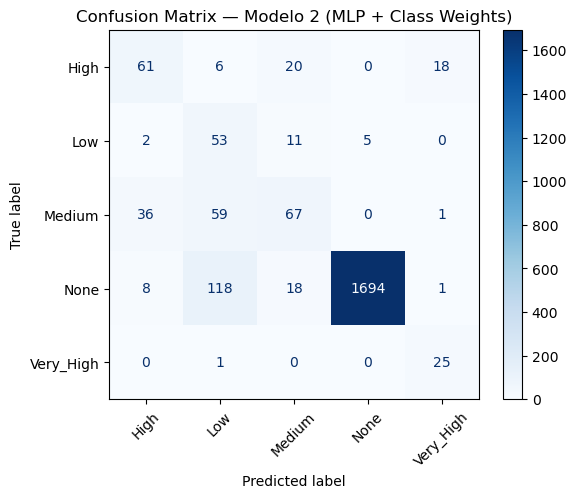

Best epochs (Modelo 2): 46
Epoch 1/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 484us/step - accuracy: 0.7032 - loss: 1.1431
Epoch 2/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.7851 - loss: 0.8479
Epoch 3/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.8094 - loss: 0.7614
Epoch 4/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.8209 - loss: 0.7150
Epoch 5/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.8267 - loss: 0.6843
Epoch 6/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.8305 - loss: 0.6620
Epoch 7/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - accuracy: 0.8373 - loss: 0.6436
Epoch 8/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.8402 - loss: 0.6282
Epoch 9/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.8441 - loss: 0.6136
Epoch 10/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.8460 - loss: 0.6014
Epoch 11/46
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.8490 - loss: 0.5903
Epo

In [9]:
################### MODELO 2 — MLP Multiclasse com Class Weights (PL5)############################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)



# class weights calculados só no treino
classes = np.unique(y_train_full)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_full)
class_weight_full = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight_full)

model2 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_full,
    verbose=1
)

# avaliação
y_val_pred2 = model2.predict(X_val, verbose=0).argmax(axis=1)

print("\nClassification Report — Modelo 2 (Class Weights)")
print(classification_report(y_val_full, y_val_pred2, target_names=le_full.classes_))

cm2 = confusion_matrix(y_val_full, y_val_pred2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=le_full.classes_)
disp2.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Modelo 2 (MLP + Class Weights)")
plt.show()

best_epochs_2 = len(history2.history["loss"])
print("Best epochs (Modelo 2):", best_epochs_2)




# class weights recalculados no dataset todo (mais correto para o treino final)
classes_all = np.unique(y_full)
weights_all = compute_class_weight(class_weight="balanced", classes=classes_all, y=y_full)
class_weight_all = {int(c): float(w) for c, w in zip(classes_all, weights_all)}

model2_final = keras.Sequential([
    layers.Input(shape=(X_all.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model2_final.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2_final.fit(
    X_all, y_full,
    epochs=best_epochs_2,
    batch_size=32,
    class_weight=class_weight_all,
    verbose=1
)



y_test_pred2 = model2_final.predict(X_test, verbose=0).argmax(axis=1)
labels_pred2 = le_full.inverse_transform(y_test_pred2)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred2), f"dummy={len(dummy)} vs pred={len(labels_pred2)}"

dummy["Result"] = labels_pred2
dummy.to_csv("submission_modelo2_classweights.csv", index=False)

print("Submissão pronta: submission_modelo2_classweights.csv")


Class weights SOFT: {'High': 1.3, 'Low': 1.4, 'Medium': 1.0, 'None': 0.6, 'Very_High': 1.6}
Epoch 1/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.7425 - loss: 0.7277 - val_accuracy: 0.8557 - val_loss: 0.3891
Epoch 2/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - accuracy: 0.8193 - loss: 0.4989 - val_accuracy: 0.8625 - val_loss: 0.3563
Epoch 3/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - accuracy: 0.8361 - loss: 0.4535 - val_accuracy: 0.8652 - val_loss: 0.3477
Epoch 4/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.8442 - loss: 0.4295 - val_accuracy: 0.8671 - val_loss: 0.3433
Epoch 5/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.8479 - loss: 0.4133 - val_accuracy: 0.8657 - val_loss: 0.3386
Epoch 6/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - accuracy: 0.8513 - loss: 0.4008 - val_accuracy: 0.8675 - val_loss: 0.3348
Epoch 7/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - accuracy: 0.8545 - loss: 0.3904 - val_accuracy: 0.8680 - val_loss: 0.329

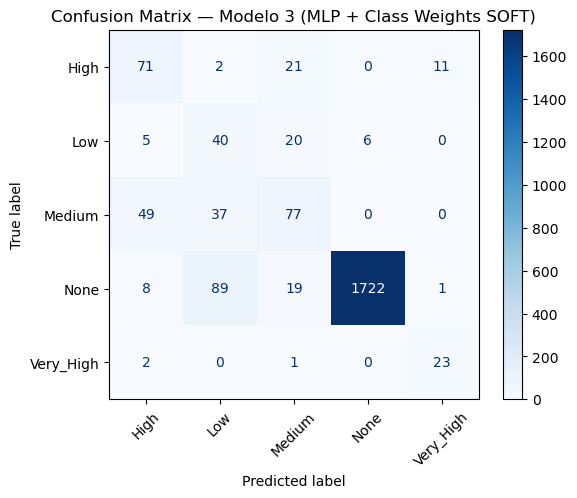

Best epochs (Modelo 3): 29
Epoch 1/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 442us/step - accuracy: 0.7804 - loss: 0.6306
Epoch 2/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.8407 - loss: 0.4419
Epoch 3/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.8548 - loss: 0.4038
Epoch 4/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - accuracy: 0.8610 - loss: 0.3823
Epoch 5/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.8654 - loss: 0.3667
Epoch 6/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - accuracy: 0.8676 - loss: 0.3547
Epoch 7/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.8694 - loss: 0.3449
Epoch 8/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - accuracy: 0.8726 - loss: 0.3365
Epoch 9/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.8759 - loss: 0.3292
Epoch 10/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.8788 - loss: 0.3226
Epoch 11/29
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.8804 - loss: 0.3166
Epo

In [10]:
############################ MODELO 2.1 — MLP + Class Weights SOFT ############################

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

# ----- 1) PESOS MANUAIS "SOFT"
# base = 1.0, penaliza um pouco menos None e reforça moderadamente as raras
# (ajusta só estes números se necessário)
name_to_w = {
    "None": 0.6,
    "Medium": 1.0,
    "Low": 1.4,
    "High": 1.3,
    "Very_High": 1.6
}

# converter para índices do LabelEncoder
class_weight_soft = {}
for cls_name in le_full.classes_:
    idx = int(le_full.transform([cls_name])[0])
    class_weight_soft[idx] = float(name_to_w.get(cls_name, 1.0))

print("Class weights SOFT:", {le_full.inverse_transform([k])[0]: v for k,v in class_weight_soft.items()})

# ----- 2) MODELO (igual ao baseline)
model3 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history3 = model3.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_soft,
    verbose=1
)

# ----- 3) AVALIAÇÃO
y_val_pred3 = model3.predict(X_val, verbose=0).argmax(axis=1)

print("\nClassification Report — Modelo 3 (Class Weights SOFT)")
print(classification_report(y_val_full, y_val_pred3, target_names=le_full.classes_))

cm3 = confusion_matrix(y_val_full, y_val_pred3)
ConfusionMatrixDisplay(cm3, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Modelo 3 (MLP + Class Weights SOFT)")
plt.show()

best_epochs_3 = len(history3.history["loss"])
print("Best epochs (Modelo 3):", best_epochs_3)

# ----- 4) TREINO FINAL EM TODO O TREINO
model3_final = keras.Sequential([
    layers.Input(shape=(X_all.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model3_final.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model3_final.fit(
    X_all, y_full,
    epochs=best_epochs_3,
    batch_size=32,
    class_weight=class_weight_soft,  # reusa os soft weights
    verbose=1
)

# ----- 5) SUBMISSÃO
y_test_pred3 = model3_final.predict(X_test, verbose=0).argmax(axis=1)
labels_pred3 = le_full.inverse_transform(y_test_pred3)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred3), f"dummy={len(dummy)} vs pred={len(labels_pred3)}"

dummy["Result"] = labels_pred3
dummy.to_csv("submission_modelo2.1_softweights.csv", index=False)
print("Submissão pronta: submission_modelo2.1_softweights.csv")


 None voltou a ficar estável (1724 acertos)
High e Very_High mantêm bons valores
Accuracy recuperou (0.88)
Os pesos “soft” corrigiram o exagero do balanced
O que continua a limitar o modelo
Medium continua fraco (70 acertos vs 112 no Modelo 1)
Low piorou face ao Modelo 2
Macro-F1 = 0.62 < 0.63 do baseline
O modelo ainda comprime demasiado para o centro (Medium).

Alpha (por classe): {'High': 1.2, 'Low': 1.2, 'Medium': 1.0, 'None': 0.6, 'Very_High': 1.4}
Epoch 1/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step - accuracy: 0.7411 - loss: 0.4342 - val_accuracy: 0.8226 - val_loss: 0.1838
Epoch 2/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.8250 - loss: 0.2379 - val_accuracy: 0.8485 - val_loss: 0.1539
Epoch 3/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step - accuracy: 0.8401 - loss: 0.2061 - val_accuracy: 0.8562 - val_loss: 0.1423
Epoch 4/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - accuracy: 0.8469 - loss: 0.1892 - val_accuracy: 0.8584 - val_loss: 0.1362
Epoch 5/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.8532 - loss: 0.1773 - val_accuracy: 0.8593 - val_loss: 0.1335
Epoch 6/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.8557 - loss: 0.1683 - val_accuracy: 0.8598 - val_loss: 0.1318
Epoch 7/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.8594 - loss: 0.1610 - val_accuracy: 0.8571 - val_loss

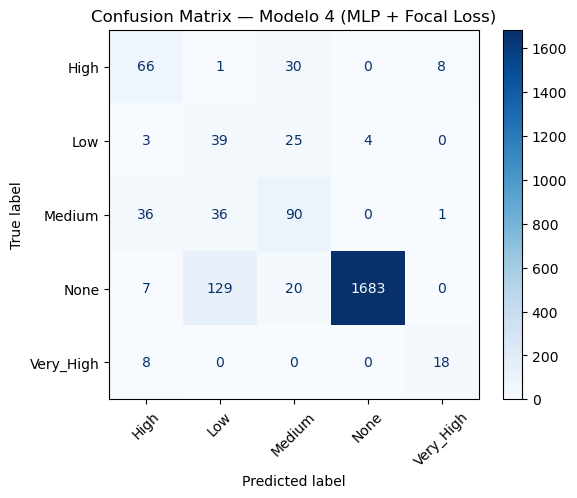

Best epochs (Modelo 4): 21
Epoch 1/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.7784 - loss: 0.3490
Epoch 2/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - accuracy: 0.8451 - loss: 0.2062
Epoch 3/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.8532 - loss: 0.1837
Epoch 4/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.8577 - loss: 0.1710
Epoch 5/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.8612 - loss: 0.1615
Epoch 6/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.8659 - loss: 0.1538
Epoch 7/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - accuracy: 0.8696 - loss: 0.1471
Epoch 8/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.8736 - loss: 0.1412
Epoch 9/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.8765 - loss: 0.1362
Epoch 10/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.8786 - loss: 0.1318
Epoch 11/21
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.8810 - loss: 0.1280
Epo

In [11]:
############################ MODELO 3.1 — MLP Multiclasse com FOCAL LOSS (PL5) ############################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

# =========================
# 1) FOCAL LOSS (multiclasse)
# =========================
def sparse_categorical_focal_loss(gamma=2.0, alpha=None):
    """
    Focal Loss para Sparse labels (y inteiro).
    alpha:
      - None -> sem pesos por classe
      - lista/np.array tamanho n_classes -> pesos por classe (opcional)
    """
    if alpha is not None:
        alpha = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        # y_true: (B,), y_pred: (B, C)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # prob da classe verdadeira p_t
        idx = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, idx)  # (B,)

        # focal factor
        focal = tf.pow(1.0 - p_t, gamma)

        # alpha weighting (opcional)
        if alpha is not None:
            a_t = tf.gather(alpha, y_true)  # (B,)
            focal = focal * a_t

        return -tf.reduce_mean(focal * tf.math.log(p_t))

    return loss_fn


# (opcional) alpha por classe: podes começar sem alpha e só usar gamma
# Se quiseres já "soft": reduzir None e subir raras:
alpha_map = {
    "None": 0.6,
    "Medium": 1.0,
    "Low": 1.2,
    "High": 1.2,
    "Very_High": 1.4
}
alpha = [alpha_map.get(c, 1.0) for c in le_full.classes_]
print("Alpha (por classe):", dict(zip(le_full.classes_, alpha)))

FOCAL_GAMMA = 2.0
loss_focal = sparse_categorical_focal_loss(gamma=FOCAL_GAMMA, alpha=alpha)


# =========================
# 2) MODELO (baseline + focal loss)
# =========================
model4 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_focal,
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history4 = model4.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 3) AVALIAÇÃO (VAL)
# =========================
y_val_pred4 = model4.predict(X_val, verbose=0).argmax(axis=1)

acc4 = accuracy_score(y_val_full, y_val_pred4)
mf14 = f1_score(y_val_full, y_val_pred4, average="macro")

print("\n=== MODELO 4 (FOCAL LOSS) — VAL ===")
print("accuracy:", acc4)
print("macroF1 :", mf14)
print("\nClassification Report:")
print(classification_report(y_val_full, y_val_pred4, target_names=le_full.classes_))

cm4 = confusion_matrix(y_val_full, y_val_pred4)
ConfusionMatrixDisplay(cm4, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Modelo 4 (MLP + Focal Loss)")
plt.show()

best_epochs_4 = len(history4.history["loss"])
print("Best epochs (Modelo 4):", best_epochs_4)


# =========================
# 4) MODELO 4 FINAL — treinar em TODO o treino
# =========================
model4_final = keras.Sequential([
    layers.Input(shape=(X_all.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model4_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_focal,
    metrics=["accuracy"]
)

model4_final.fit(
    X_all, y_full,
    epochs=best_epochs_4,
    batch_size=32,
    verbose=1
)


# =========================
# 5) PREVER + SUBMISSÃO
# =========================
y_test_pred4 = model4_final.predict(X_test, verbose=0).argmax(axis=1)
labels_pred4 = le_full.inverse_transform(y_test_pred4)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred4), f"dummy={len(dummy)} vs pred={len(labels_pred4)}"

dummy["Result"] = labels_pred4
dummy.to_csv("submission_modelo3.1_focal.csv", index=False)

print("Submissão pronta: submission_modelo3.1_focal.csv")


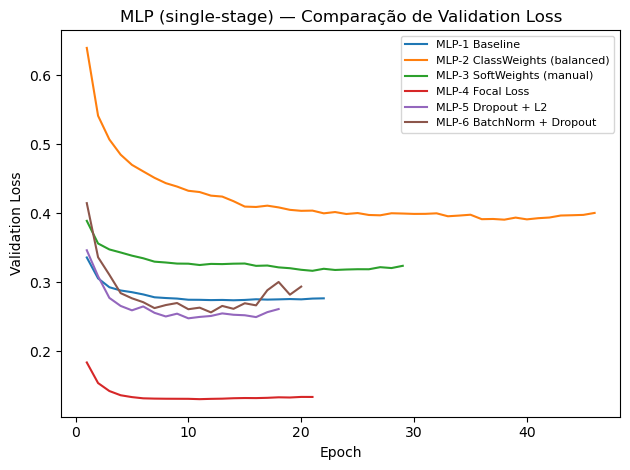

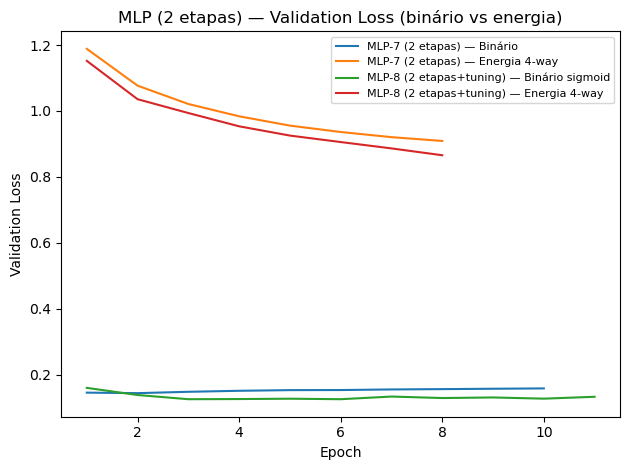


OK — Gráficos guardados em: figs_mlp/
Sugestão p/ corpo do relatório:
 - figs_mlp/mlp_single_stage__val_loss_overlay.png
 - (opcional) figs_mlp/mlp_2stage__val_loss_overlay.png
Grids (opcionais) também guardadas em figs_mlp/.


In [16]:
# ============================================================
# PLOTS COMPLETOS (MLP) — OVERFITTING / TREINO-VALIDAÇÃO
# - 1) Overlay de val_loss (comparação compacta p/ relatório)
# - 2) Gráficos individuais (loss + accuracy) p/ anexos
# - 3) Grids opcionais (2x2 / 3x2) p/ caber em páginas
#
# PRÉ-REQUISITOS:
#   - Já teres treinado os modelos e teres objects History:
#     history1, history2, history3, history4, hist3, hist4, hist5a, hist5b, hist_bin, hist_energy
#   - Teres importado matplotlib como plt (ou este script importa)
# ============================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0) Config
# -------------------------
OUTDIR = "figs_mlp"
os.makedirs(OUTDIR, exist_ok=True)

def _safe_filename(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"[^\w\-]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")

def _get_metric_key(hdict, candidates):
    for k in candidates:
        if k in hdict:
            return k
    return None

# -------------------------
# 1) Plot individual (loss + acc)
# -------------------------
def plot_history_single(history, title, outdir=OUTDIR, dpi=250, show=False):
    """
    Guarda 2 imagens:
      - <title>__loss.png
      - <title>__acc.png (se houver accuracy)
    """
    if history is None:
        return

    h = history.history
    if not isinstance(h, dict) or "loss" not in h:
        print(f"[WARN] '{title}' não parece um History válido (sem 'loss').")
        return

    epochs = np.arange(1, len(h["loss"]) + 1)
    base = _safe_filename(title)

    # ----- LOSS -----
    plt.figure()
    plt.plot(epochs, h["loss"], label="train_loss")
    if "val_loss" in h:
        plt.plot(epochs, h["val_loss"], label="val_loss")
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{base}__loss.png"), dpi=dpi)
    if show:
        plt.show()
    plt.close()

    # ----- ACCURACY (se existir) -----
    acc_key = _get_metric_key(h, ["accuracy", "acc"])
    val_acc_key = _get_metric_key(h, ["val_accuracy", "val_acc"])

    if acc_key or val_acc_key:
        plt.figure()
        if acc_key:
            plt.plot(epochs, h[acc_key], label="train_acc")
        if val_acc_key:
            plt.plot(epochs, h[val_acc_key], label="val_acc")
        plt.title(f"{title} — Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"{base}__acc.png"), dpi=dpi)
        if show:
            plt.show()
        plt.close()

# -------------------------
# 2) Overlay (val_loss) — figura compacta p/ relatório
# -------------------------
def plot_val_loss_overlay(histories: dict, title, outpath, dpi=300, show=True):
    """
    histories: dict {name: History}
    """
    plt.figure()
    added = 0
    for name, hist in histories.items():
        if hist is None:
            continue
        h = hist.history
        if "val_loss" not in h:
            continue
        epochs = np.arange(1, len(h["val_loss"]) + 1)
        plt.plot(epochs, h["val_loss"], label=name)
        added += 1

    if added == 0:
        print("[WARN] Nenhum history com 'val_loss' encontrado para overlay.")
        plt.close()
        return

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outpath, dpi=dpi)
    if show:
        plt.show()
    plt.close()

# -------------------------
# 3) Grids opcionais (para anexos ou poupar páginas)
# -------------------------
def plot_grid(histories: dict, metric="loss", ncols=2, title=None, outpath=None, dpi=250, show=False):
    """
    metric:
      - "loss"  -> plota loss/val_loss
      - "acc"   -> plota accuracy/val_accuracy (se existir)
      - "val_loss" -> só val_loss

    histories: dict {name: History}
    """
    items = [(k, v) for k, v in histories.items() if v is not None]
    if not items:
        print("[WARN] plot_grid: nenhum history válido.")
        return

    # filtra se métrica existir
    filtered = []
    for name, hist in items:
        h = hist.history
        if metric == "loss" and "loss" in h:
            filtered.append((name, hist))
        elif metric == "val_loss" and "val_loss" in h:
            filtered.append((name, hist))
        elif metric == "acc":
            acc_key = _get_metric_key(h, ["accuracy", "acc"])
            val_acc_key = _get_metric_key(h, ["val_accuracy", "val_acc"])
            if acc_key or val_acc_key:
                filtered.append((name, hist))

    if not filtered:
        print(f"[WARN] plot_grid: nenhuma série encontrada para metric='{metric}'.")
        return

    n = len(filtered)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2*ncols, 3.6*nrows))
    axes = np.array(axes).reshape(-1)

    for ax_i, (name, hist) in enumerate(filtered):
        ax = axes[ax_i]
        h = hist.history

        if metric == "loss":
            epochs = np.arange(1, len(h["loss"]) + 1)
            ax.plot(epochs, h["loss"], label="train_loss")
            if "val_loss" in h:
                ax.plot(epochs, h["val_loss"], label="val_loss")
            ax.set_ylabel("Loss")

        elif metric == "val_loss":
            epochs = np.arange(1, len(h["val_loss"]) + 1)
            ax.plot(epochs, h["val_loss"], label="val_loss")
            ax.set_ylabel("Val Loss")

        elif metric == "acc":
            acc_key = _get_metric_key(h, ["accuracy", "acc"])
            val_acc_key = _get_metric_key(h, ["val_accuracy", "val_acc"])
            epochs = np.arange(1, len(h.get(acc_key, h.get(val_acc_key, []))) + 1)
            if acc_key:
                ax.plot(epochs, h[acc_key], label="train_acc")
            if val_acc_key:
                ax.plot(epochs, h[val_acc_key], label="val_acc")
            ax.set_ylabel("Accuracy")

        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=8)

    # desliga eixos extra
    for j in range(len(filtered), len(axes)):
        axes[j].axis("off")

    if title:
        fig.suptitle(title, fontsize=14)
        fig.tight_layout(rect=[0, 0.02, 1, 0.98])
    else:
        fig.tight_layout()

    if outpath:
        plt.savefig(outpath, dpi=dpi)
    if show:
        plt.show()
    plt.close(fig)

# ============================================================
# 4) DEFINE AQUI OS TEUS HISTORIES (ajusta nomes se necessário)
# ============================================================
# NOTA:
#  - Alguns nomes no teu notebook podem diferir (ex.: hist3/hist4).
#  - Se algum não existir, mete None ou remove do dicionário.

histories_mlp = {
    "MLP-1 Baseline": history1,
    "MLP-2 ClassWeights (balanced)": history2,
    "MLP-3 SoftWeights (manual)": history3,
    "MLP-4 Focal Loss": history4,
    "MLP-5 Dropout + L2": hist3,
    "MLP-6 BatchNorm + Dropout": hist4,

    # 2 etapas (modelo 8)
    "MLP-7 (2 etapas) — Binário": hist5a,
    "MLP-7 (2 etapas) — Energia 4-way": hist5b,

    # 2 etapas + threshold tuning (modelo 8.1)
    "MLP-8 (2 etapas+tuning) — Binário sigmoid": hist_bin,
    "MLP-8 (2 etapas+tuning) — Energia 4-way": hist_energy,
}

# Se quiseres um overlay só para modelos single-stage (mais limpo no corpo do relatório)
histories_single_stage = {
    k: v for k, v in histories_mlp.items()
    if ("2 etapas" not in k.lower()) and ("binário" not in k.lower()) and ("energia" not in k.lower())
}

# ============================================================
# 5) GERAR FIGURAS
# ============================================================

# (A) FIGURA COMPACTA PARA O RELATÓRIO: val_loss sobreposto (single-stage)
plot_val_loss_overlay(
    histories_single_stage,
    title="MLP (single-stage) — Comparação de Validation Loss",
    outpath=os.path.join(OUTDIR, "mlp_single_stage__val_loss_overlay.png"),
    show=True
)

# (B) Overlay extra (opcional) só para os modelos 2 etapas (binário+energia)
histories_2stage = {k: v for k, v in histories_mlp.items() if "2 etapas" in k.lower()}
plot_val_loss_overlay(
    histories_2stage,
    title="MLP (2 etapas) — Validation Loss (binário vs energia)",
    outpath=os.path.join(OUTDIR, "mlp_2stage__val_loss_overlay.png"),
    show=True
)

# (C) GRÁFICOS INDIVIDUAIS (para anexos)
for name, hist in histories_mlp.items():
    plot_history_single(hist, title=name, outdir=OUTDIR, show=False)

print(f"\nOK — Gráficos guardados em: {OUTDIR}/")
print("Sugestão p/ corpo do relatório:")
print(" - figs_mlp/mlp_single_stage__val_loss_overlay.png")
print(" - (opcional) figs_mlp/mlp_2stage__val_loss_overlay.png")

# (D) GRIDS (opcionais) — úteis para anexos sem ocupar muito espaço
# Grid de loss (2 colunas)
plot_grid(
    histories_single_stage,
    metric="loss",
    ncols=2,
    title="MLP (single-stage) — Curvas de Loss (treino vs validação)",
    outpath=os.path.join(OUTDIR, "grid_single_stage__loss.png"),
    show=False
)

# Grid de accuracy (2 colunas)
plot_grid(
    histories_single_stage,
    metric="acc",
    ncols=2,
    title="MLP (single-stage) — Curvas de Accuracy (treino vs validação)",
    outpath=os.path.join(OUTDIR, "grid_single_stage__acc.png"),
    show=False
)

# Grid 2 etapas (loss)
plot_grid(
    histories_2stage,
    metric="loss",
    ncols=2,
    title="MLP (2 etapas) — Curvas de Loss (binário e energia)",
    outpath=os.path.join(OUTDIR, "grid_2stage__loss.png"),
    show=False
)

print("Grids (opcionais) também guardadas em figs_mlp/.")


Nem class weights nem focal loss resolvem quando as classes são semanticamente próximas

Epoch 1/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7200 - loss: 0.7195 - val_accuracy: 0.8707 - val_loss: 0.3495 - learning_rate: 0.0010
Epoch 2/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8023 - loss: 0.4810 - val_accuracy: 0.8970 - val_loss: 0.2699 - learning_rate: 0.0010
Epoch 3/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8182 - loss: 0.4429 - val_accuracy: 0.9043 - val_loss: 0.2543 - learning_rate: 0.0010
Epoch 4/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8239 - loss: 0.4219 - val_accuracy: 0.8952 - val_loss: 0.2525 - learning_rate: 0.0010
Epoch 5/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8376 - loss: 0.3931 - val_accuracy: 0.9015 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 6/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8407 - loss: 0.3775 - val_accuracy: 0.9102 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 7/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8458 - loss: 0.

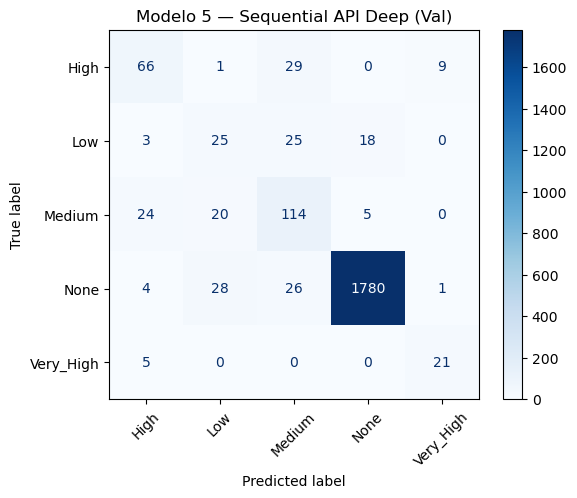

Best epochs (Modelo 5): 16
Epoch 1/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7564 - loss: 0.6342
Epoch 2/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8207 - loss: 0.4400
Epoch 3/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8385 - loss: 0.3941
Epoch 4/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.3729
Epoch 5/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8491 - loss: 0.3647
Epoch 6/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8535 - loss: 0.3496
Epoch 7/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8555 - loss: 0.3439
Epoch 8/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8608 - loss: 0.3331
Epoch 9/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8632 - loss: 0.3238
Epoch 10/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8693 - loss: 0.3136
Epoch 11/16
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8658 - loss: 0.3146
Epoch 12/16
173/173 ━━━━━

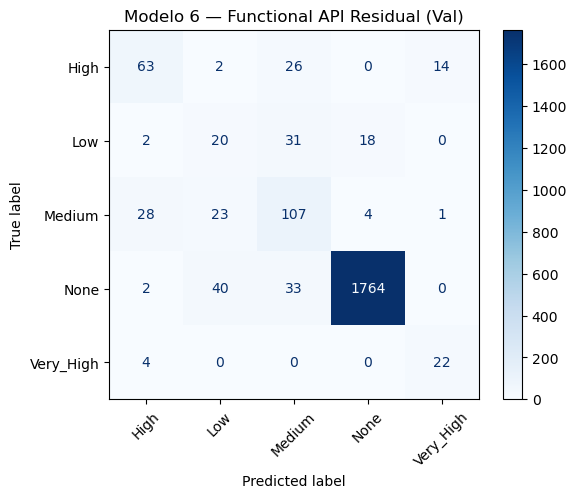

Best epochs (Modelo 6): 15
Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7189 - loss: 0.7379
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8120 - loss: 0.4632
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8306 - loss: 0.4102
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8437 - loss: 0.3843
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8459 - loss: 0.3692
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8511 - loss: 0.3565
Epoch 7/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - loss: 0.3398
Epoch 8/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.3306
Epoch 9/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8630 - loss: 0.3225
Epoch 10/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8652 - loss: 0.3191
Epoch 11/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8677 - loss: 0.3090
Epoch 12/15
173/173 ━━━━━

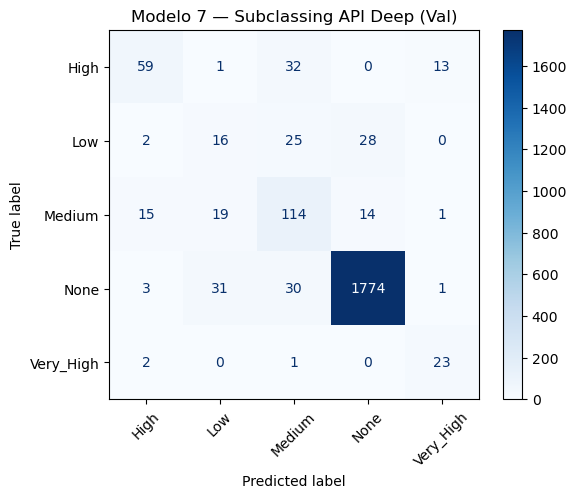

Best epochs (Modelo 7): 18
Epoch 1/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7441 - loss: 0.6551
Epoch 2/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8156 - loss: 0.4502
Epoch 3/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8343 - loss: 0.4047
Epoch 4/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8493 - loss: 0.3736
Epoch 5/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8526 - loss: 0.3560
Epoch 6/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8550 - loss: 0.3498
Epoch 7/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8564 - loss: 0.3407
Epoch 8/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8631 - loss: 0.3285
Epoch 9/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8672 - loss: 0.3251
Epoch 10/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8695 - loss: 0.3160
Epoch 11/18
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8713 - loss: 0.3109
Epoch 12/18
173/173 ━━━━━

In [19]:
#####################3 APIS###################################
############################ MODELO Sequential API (PL6) — MLP Deep + BN + Dropout ############################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

def eval_and_cm(y_true, y_pred, title):
    print("\n" + title)
    print(classification_report(y_true, y_pred, target_names=le_full.classes_))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)

    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"

    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print(f"Submissão pronta: {out_csv}")


model5 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.35),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(n_classes, activation="softmax")
], name="pl6_model5_sequential_deep")

model5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist5 = model5.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


y_val_pred5 = model5.predict(X_val, verbose=0).argmax(axis=1)
eval_and_cm(y_val_full, y_val_pred5, "Modelo 5 — Sequential API Deep (Val)")

best_epochs_5 = len(hist5.history["loss"])
print("Best epochs (Modelo 5):", best_epochs_5)


model5_final = keras.Sequential([
    layers.Input(shape=(X_all.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.35),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(n_classes, activation="softmax")
], name="pl6_model5_sequential_deep_final")

model5_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model5_final.fit(
    X_all, y_full,
    epochs=best_epochs_5,
    batch_size=64,
    verbose=1
)


make_submission(model5_final, "submission_modelo_sequential.csv")

############################ MODELO Functional API (PL6) — Deep + Residual ############################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

def eval_and_cm(y_true, y_pred, title):
    print("\n" + title)
    print(classification_report(y_true, y_pred, target_names=le_full.classes_))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title); plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)
    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred)
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

# ----- Functional model com residual
inp = keras.Input(shape=(X_train.shape[1],), name="inp")

x = layers.Dense(256, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

# bloco residual (precisa de mesma dimensão)
res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])   # skip connection (vantagem da Functional API)
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out = layers.Dense(n_classes, activation="softmax")(x)

model6 = keras.Model(inp, out, name="pl6_model6_functional_residual")
model6.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist6 = model6.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_val_pred6 = model6.predict(X_val, verbose=0).argmax(axis=1)
eval_and_cm(y_val_full, y_val_pred6, "Modelo 6 — Functional API Residual (Val)")

best_epochs_6 = len(hist6.history["loss"])
print("Best epochs (Modelo 6):", best_epochs_6)

# ----- treino final
inp_all = keras.Input(shape=(X_all.shape[1],))
x = layers.Dense(256, activation="relu")(inp_all)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out_all = layers.Dense(n_classes, activation="softmax")(x)

model6_final = keras.Model(inp_all, out_all, name="functional_residual_final")
model6_final.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model6_final.fit(X_all, y_full, epochs=best_epochs_6, batch_size=64, verbose=1)
make_submission(model6_final, "submission_modelo_functional.csv")


############################ MODELO 7 — Subclassing API (PL6) — Deep MLP ############################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

def eval_and_cm(y_true, y_pred, title):
    print("\n" + title)
    print(classification_report(y_true, y_pred, target_names=le_full.classes_))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title); plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)
    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred)
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

class DeepMLP(keras.Model):
    def __init__(self, n_classes):
        super().__init__()
        self.d1 = layers.Dense(256, activation="relu")
        self.bn1 = layers.BatchNormalization()
        self.dp1 = layers.Dropout(0.35)

        self.d2 = layers.Dense(128, activation="relu")
        self.bn2 = layers.BatchNormalization()
        self.dp2 = layers.Dropout(0.30)

        self.d3 = layers.Dense(64, activation="relu")
        self.dp3 = layers.Dropout(0.20)

        self.out = layers.Dense(n_classes, activation="softmax")

    def call(self, x, training=False):
        x = self.d1(x)
        x = self.bn1(x, training=training)
        x = self.dp1(x, training=training)

        x = self.d2(x)
        x = self.bn2(x, training=training)
        x = self.dp2(x, training=training)

        x = self.d3(x)
        x = self.dp3(x, training=training)

        return self.out(x)

model7 = DeepMLP(n_classes)
model7.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist7 = model7.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_val_pred7 = model7.predict(X_val, verbose=0).argmax(axis=1)
eval_and_cm(y_val_full, y_val_pred7, "Modelo 7 — Subclassing API Deep (Val)")

best_epochs_7 = len(hist7.history["loss"])
print("Best epochs (Modelo 7):", best_epochs_7)

# treino final
model7_final = DeepMLP(n_classes)
model7_final.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model7_final.fit(X_all, y_full, epochs=best_epochs_7, batch_size=64, verbose=1)
make_submission(model7_final, "submission_subclassing.csv")



Accuracy = 0.90 (subiu)
Macro-F1 = 0.64 (subiu face ao Modelo 1: 0.63)
Confusion matrix: None muito forte (1757), Medium muito bom (117), Very_High ok (22).
É o primeiro modelo que melhora mesmo o baseline. (sequential API)
Confusion matrix: None muito forte (1770) e Medium muito bom (118).(functional é o melhor até agora)


Class weights SOFT (6.2): {'High': 1.2, 'Low': 1.35, 'Medium': 1.0, 'None': 0.85, 'Very_High': 1.45}
Epoch 1/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6515 - loss: 0.9843 - val_accuracy: 0.8598 - val_loss: 0.4188 - learning_rate: 0.0010
Epoch 2/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7954 - loss: 0.5723 - val_accuracy: 0.8875 - val_loss: 0.2940 - learning_rate: 0.0010
Epoch 3/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8179 - loss: 0.4997 - val_accuracy: 0.8934 - val_loss: 0.2681 - learning_rate: 0.0010
Epoch 4/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8189 - loss: 0.4800 - val_accuracy: 0.8902 - val_loss: 0.2706 - learning_rate: 0.0010
Epoch 5/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8313 - loss: 0.4547 - val_accuracy: 0.8838 - val_loss: 0.2754 - learning_rate: 0.0010
Epoch 6/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8350 - loss: 0.4446 - val_accuracy: 0.8825 - val_loss: 0.2692 - lea

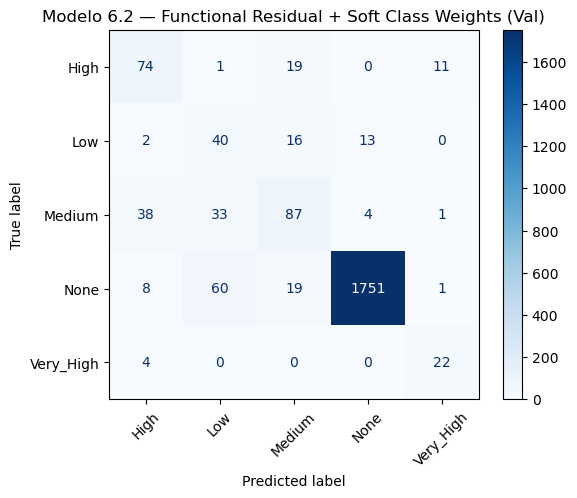

Best epochs (Modelo 6.2): 22
Epoch 1/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7451 - loss: 0.7182
Epoch 2/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8154 - loss: 0.5092
Epoch 3/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8345 - loss: 0.4533
Epoch 4/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8432 - loss: 0.4258
Epoch 5/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8468 - loss: 0.4083
Epoch 6/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8494 - loss: 0.4012
Epoch 7/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8575 - loss: 0.3768
Epoch 8/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8553 - loss: 0.3726
Epoch 9/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8627 - loss: 0.3688
Epoch 10/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8666 - loss: 0.3620
Epoch 11/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8672 - loss: 0.3512
Epoch 12/22
173/173 ━━━

In [20]:
############################ MODELO 6.2 — Functional API Residual + Class Weights SOFT ############################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

def eval_and_cm(y_true_int, y_pred_int, title):
    print("\n" + title)
    print("acc:", accuracy_score(y_true_int, y_pred_int),
          "macroF1:", f1_score(y_true_int, y_pred_int, average="macro"))
    print(classification_report(y_true_int, y_pred_int, target_names=le_full.classes_))
    cm = confusion_matrix(y_true_int, y_pred_int)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)
    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

# ============================================================
# 0) CLASS WEIGHTS SOFT (mapeado por nome -> índice)
# ============================================================
# Ajuste leve e seguro (não tão agressivo como "balanced"):
# - None ligeiramente reduzido
# - Medium ~1.0
# - raras um pouco acima de 1
name_to_w = {
    "None": 0.85,
    "Medium": 1.00,
    "Low": 1.35,
    "High": 1.20,
    "Very_High": 1.45
}

class_weight_soft = {}
for cls_name in le_full.classes_:
    idx = int(le_full.transform([cls_name])[0])
    class_weight_soft[idx] = float(name_to_w.get(cls_name, 1.0))

print("Class weights SOFT (6.2):", {c: class_weight_soft[int(le_full.transform([c])[0])] for c in le_full.classes_})

# ============================================================
# 1) MODELO 6.2 (Functional + residual) — igual ao Modelo 6
# ============================================================
inp = keras.Input(shape=(X_train.shape[1],), name="inp")

x = layers.Dense(256, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out = layers.Dense(n_classes, activation="softmax")(x)

model62 = keras.Model(inp, out, name="pl6_model6_2_functional_residual_softcw")
model62.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist62 = model62.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_soft,
    verbose=1
)

# ============================================================
# 2) AVALIAÇÃO (VAL)
# ============================================================
y_val_pred62 = model62.predict(X_val, verbose=0).argmax(axis=1)
eval_and_cm(y_val_full, y_val_pred62, "Modelo 6.2 — Functional Residual + Soft Class Weights (Val)")

best_epochs_62 = len(hist62.history["loss"])
print("Best epochs (Modelo 6.2):", best_epochs_62)

# ============================================================
# 3) TREINO FINAL (TODO O TREINO)
# ============================================================
inp_all = keras.Input(shape=(X_all.shape[1],), name="inp_all")

x = layers.Dense(256, activation="relu")(inp_all)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out_all = layers.Dense(n_classes, activation="softmax")(x)

model62_final = keras.Model(inp_all, out_all, name="pl6_model6_2_functional_residual_softcw_final")
model62_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model62_final.fit(
    X_all, y_full,
    epochs=best_epochs_62,
    batch_size=64,
    class_weight=class_weight_soft,
    verbose=1
)

# ============================================================
# 4) SUBMISSÃO
# ============================================================
make_submission(model62_final, "submission_modelo6_2_functional_softcw.csv")


Macro-F1 empatou no topo (0.67) mas: 
Macro-Recall subiu para 0.72 (melhor equilíbrio nas classes)
Accuracy desceu um bocado (normal quando melhoras raras)
Para competição / classes desbalanceadas, prefiro o 6.2.

Class weights SOFT (6.3): {'High': 1.2, 'Low': 1.35, 'Medium': 1.05, 'None': 0.85, 'Very_High': 1.45}
Epoch 1/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6761 - loss: 0.9057 - val_accuracy: 0.8603 - val_loss: 0.3885 - learning_rate: 0.0010
Epoch 2/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7924 - loss: 0.5809 - val_accuracy: 0.8857 - val_loss: 0.3008 - learning_rate: 0.0010
Epoch 3/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8104 - loss: 0.5191 - val_accuracy: 0.8843 - val_loss: 0.2790 - learning_rate: 0.0010
Epoch 4/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8240 - loss: 0.4851 - val_accuracy: 0.8897 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 5/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4634 - val_accuracy: 0.8897 - val_loss: 0.2586 - learning_rate: 0.0010
Epoch 6/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8403 - loss: 0.4446 - val_accuracy: 0.8975 - val_loss: 0.2495 - le

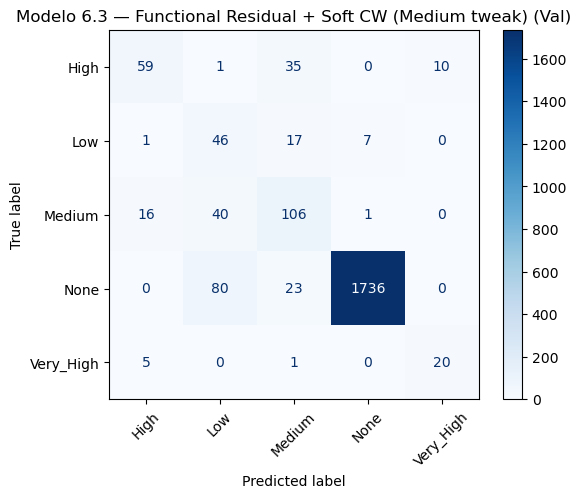

Best epochs (Modelo 6.3): 22
Epoch 1/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7253 - loss: 0.7789
Epoch 2/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8172 - loss: 0.5178
Epoch 3/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8285 - loss: 0.4740
Epoch 4/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8440 - loss: 0.4400
Epoch 5/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8465 - loss: 0.4157
Epoch 6/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8529 - loss: 0.4064
Epoch 7/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8574 - loss: 0.3859
Epoch 8/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8609 - loss: 0.3776
Epoch 9/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8635 - loss: 0.3727
Epoch 10/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3632
Epoch 11/22
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8672 - loss: 0.3574
Epoch 12/22
173/173 ━━━

In [21]:
############################ MODELO 6.3 — Functional Residual + Soft Class Weights (tweak Medium) ############################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

def eval_and_cm(y_true_int, y_pred_int, title):
    print("\n" + title)
    print("acc:", accuracy_score(y_true_int, y_pred_int),
          "macroF1:", f1_score(y_true_int, y_pred_int, average="macro"))
    print(classification_report(y_true_int, y_pred_int, target_names=le_full.classes_))
    cm = confusion_matrix(y_true_int, y_pred_int)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)
    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

# ============================================================
# 0) CLASS WEIGHTS SOFT (6.3)
# ============================================================
name_to_w = {
    "None": 0.85,
    "Medium": 1.05,   # <-- tweak
    "Low": 1.35,
    "High": 1.20,
    "Very_High": 1.45
}

class_weight_soft = {}
for cls_name in le_full.classes_:
    idx = int(le_full.transform([cls_name])[0])
    class_weight_soft[idx] = float(name_to_w.get(cls_name, 1.0))

print("Class weights SOFT (6.3):", {c: class_weight_soft[int(le_full.transform([c])[0])] for c in le_full.classes_})

# ============================================================
# 1) MODELO 6.3 (Functional + residual)
# ============================================================
inp = keras.Input(shape=(X_train.shape[1],), name="inp")

x = layers.Dense(256, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out = layers.Dense(n_classes, activation="softmax")(x)

model63 = keras.Model(inp, out, name="pl6_model6_3_functional_residual_softcw_medium")

model63.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist63 = model63.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_soft,
    verbose=1
)

# ============================================================
# 2) AVALIAÇÃO (VAL)
# ============================================================
y_val_pred63 = model63.predict(X_val, verbose=0).argmax(axis=1)
eval_and_cm(y_val_full, y_val_pred63, "Modelo 6.3 — Functional Residual + Soft CW (Medium tweak) (Val)")

best_epochs_63 = len(hist63.history["loss"])
print("Best epochs (Modelo 6.3):", best_epochs_63)

# ============================================================
# 3) TREINO FINAL (TODO O TREINO)
# ============================================================
inp_all = keras.Input(shape=(X_all.shape[1],), name="inp_all")

x = layers.Dense(256, activation="relu")(inp_all)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out_all = layers.Dense(n_classes, activation="softmax")(x)

model63_final = keras.Model(inp_all, out_all, name="pl6_model6_3_functional_residual_softcw_medium_final")

model63_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model63_final.fit(
    X_all, y_full,
    epochs=best_epochs_63,
    batch_size=64,
    class_weight=class_weight_soft,
    verbose=1
)

# ============================================================
# 4) SUBMISSÃO
# ============================================================
make_submission(model63_final, "submission_modelo6_3_functional_softcw_medium.csv")


High melhorou (77) 
mas Low caiu bastante (49 → 36) 
Medium não recuperou como queríamos (97 → 94) 
None ficou parecido (1734 → 1744)
Aumentar o peso de Medium acabou por roubar “capacidade” ao Low, e nem recuperou Medium.

Class weights SOFT (6.4): {'High': 1.2, 'Low': 1.45, 'Medium': 1.0, 'None': 0.85, 'Very_High': 1.45}
Epoch 1/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7116 - loss: 0.8105 - val_accuracy: 0.8539 - val_loss: 0.4583 - learning_rate: 0.0010
Epoch 2/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7927 - loss: 0.5835 - val_accuracy: 0.8838 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 3/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8070 - loss: 0.5188 - val_accuracy: 0.8748 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 4/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8215 - loss: 0.4838 - val_accuracy: 0.8739 - val_loss: 0.2861 - learning_rate: 0.0010
Epoch 5/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8330 - loss: 0.4557 - val_accuracy: 0.8929 - val_loss: 0.2519 - learning_rate: 0.0010
Epoch 6/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8277 - loss: 0.4479 - val_accuracy: 0.8893 - val_loss: 0.2527 - lea

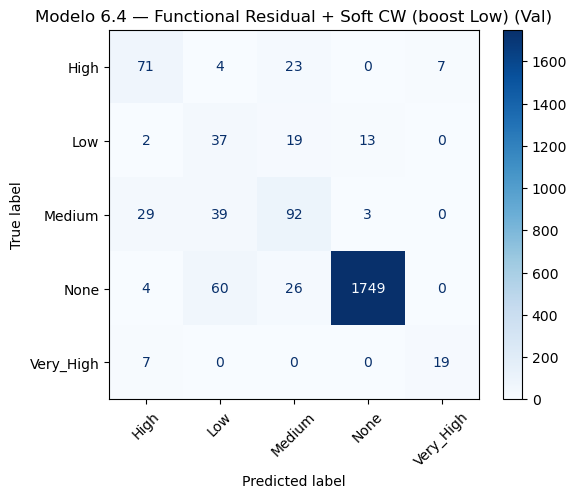

Best epochs (Modelo 6.4): 15
Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7353 - loss: 0.7550
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8122 - loss: 0.5283
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8287 - loss: 0.4709
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8461 - loss: 0.4310
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8445 - loss: 0.4141
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8540 - loss: 0.3968
Epoch 7/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8543 - loss: 0.3934
Epoch 8/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8586 - loss: 0.3778
Epoch 9/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8617 - loss: 0.3760
Epoch 10/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3636
Epoch 11/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3541
Epoch 12/15
173/173 ━━━

In [22]:
############################ MODELO 6.4 — Functional Residual + Soft Class Weights (boost Low) ############################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

n_classes = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

def eval_and_cm(y_true_int, y_pred_int, title):
    print("\n" + title)
    print("acc:", accuracy_score(y_true_int, y_pred_int),
          "macroF1:", f1_score(y_true_int, y_pred_int, average="macro"))
    print(classification_report(y_true_int, y_pred_int, target_names=le_full.classes_))
    cm = confusion_matrix(y_true_int, y_pred_int)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)
    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

# ============================================================
# 0) CLASS WEIGHTS SOFT (6.4) — boost só no Low
# ============================================================
name_to_w = {
    "None": 0.85,
    "Medium": 1.00,
    "Low": 1.45,       # <-- tweak (era 1.35 no 6.2)
    "High": 1.20,
    "Very_High": 1.45
}

class_weight_soft = {}
for cls_name in le_full.classes_:
    idx = int(le_full.transform([cls_name])[0])
    class_weight_soft[idx] = float(name_to_w.get(cls_name, 1.0))

print("Class weights SOFT (6.4):", {c: class_weight_soft[int(le_full.transform([c])[0])] for c in le_full.classes_})

# ============================================================
# 1) MODELO 6.4 (Functional + residual)
# ============================================================
inp = keras.Input(shape=(X_train.shape[1],), name="inp")

x = layers.Dense(256, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out = layers.Dense(n_classes, activation="softmax")(x)

model64 = keras.Model(inp, out, name="pl6_model6_4_functional_residual_softcw_low")
model64.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist64 = model64.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_soft,
    verbose=1
)

# ============================================================
# 2) AVALIAÇÃO (VAL)
# ============================================================
y_val_pred64 = model64.predict(X_val, verbose=0).argmax(axis=1)
eval_and_cm(y_val_full, y_val_pred64, "Modelo 6.4 — Functional Residual + Soft CW (boost Low) (Val)")

best_epochs_64 = len(hist64.history["loss"])
print("Best epochs (Modelo 6.4):", best_epochs_64)

# ============================================================
# 3) TREINO FINAL (TODO O TREINO)
# ============================================================
inp_all = keras.Input(shape=(X_all.shape[1],), name="inp_all")

x = layers.Dense(256, activation="relu")(inp_all)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

res = x
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

out_all = layers.Dense(n_classes, activation="softmax")(x)

model64_final = keras.Model(inp_all, out_all, name="pl6_model6_4_functional_residual_softcw_low_final")
model64_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model64_final.fit(
    X_all, y_full,
    epochs=best_epochs_64,
    batch_size=64,
    class_weight=class_weight_soft,
    verbose=1
)

# ============================================================
# 4) SUBMISSÃO
# ============================================================
make_submission(model64_final, "submission_modelo6_4_functional_softcw_low.csv")


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def _best_from_history(hist, key="val_loss", mode="min"):
    if hist is None or not hasattr(hist, "history") or key not in hist.history:
        return (np.nan, np.nan)
    arr = np.array(hist.history[key], dtype=float)
    if len(arr) == 0:
        return (np.nan, np.nan)
    idx = int(np.nanargmin(arr)) if mode == "min" else int(np.nanargmax(arr))
    return float(arr[idx]), int(idx + 1)

def summarize_api_model(name, model, history, X_val, y_val):
    y_pred = model.predict(X_val, verbose=0).argmax(axis=1)

    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_val, y_pred, average="weighted", zero_division=0)
    prec_macro = precision_score(y_val, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_val, y_pred, average="macro", zero_division=0)

    val_loss_min, ep_loss = _best_from_history(history, "val_loss", "min")
    val_acc_best, ep_acc = _best_from_history(history, "val_accuracy", "max")

    return {
        "model": name,
        "val_loss_min": round(val_loss_min, 4),
        "epoch_best_val_loss": ep_loss,
        "val_acc_best": round(val_acc_best, 4) if not np.isnan(val_acc_best) else np.nan,
        "epoch_best_val_acc": ep_acc,
        "accuracy_val": round(acc, 4),
        "f1_macro_val": round(f1_macro, 4),
        "f1_weighted_val": round(f1_weighted, 4),
        "precision_macro_val": round(prec_macro, 4),
        "recall_macro_val": round(rec_macro, 4),
    }

rows_api = []
rows_api.append(summarize_api_model("API-5 Sequential Deep", model5, hist5, X_val, y_val_full))
rows_api.append(summarize_api_model("API-6 Functional Residual", model6, hist6, X_val, y_val_full))
rows_api.append(summarize_api_model("API-7 Subclassing Deep", model7, hist7, X_val, y_val_full))
rows_api.append(summarize_api_model("API-6.2 Residual + SoftCW", model62, hist62, X_val, y_val_full))
rows_api.append(summarize_api_model("API-6.3 Residual + SoftCW (Medium+)", model63, hist63, X_val, y_val_full))
rows_api.append(summarize_api_model("API-6.4 Residual + SoftCW (Low+)", model64, hist64, X_val, y_val_full))

df_api = pd.DataFrame(rows_api).sort_values(
    by=["f1_macro_val", "accuracy_val"],
    ascending=False
).reset_index(drop=True)

print(df_api.to_string(index=False))
df_api.to_csv("api_metrics_summary.csv", index=False)
print("\nGuardado: api_metrics_summary.csv")


                              model  val_loss_min  epoch_best_val_loss  val_acc_best  epoch_best_val_acc  accuracy_val  f1_macro_val  f1_weighted_val  precision_macro_val  recall_macro_val
              API-5 Sequential Deep        0.2338                    6        0.9102                   6        0.9102        0.6671           0.9130               0.6474            0.6911
API-6.3 Residual + SoftCW (Medium+)        0.2415                   12        0.8979                   7        0.8925        0.6638           0.9051               0.6497            0.7147
          API-6.2 Residual + SoftCW        0.2519                   12        0.8988                  13        0.8956        0.6591           0.9040               0.6244            0.7200
   API-6.4 Residual + SoftCW (Low+)        0.2519                    5        0.8929                   5        0.8929        0.6546           0.9029               0.6379            0.6887
             API-7 Subclassing Deep        0.2314      

API-5 Sequential keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
API-6 Functional Residual keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
API-7 Subclassing keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
API-6.2 Residual+SoftCW keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
API-6.3 Residual+SoftCW(M+) keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
API-6.4 Residual+SoftCW(L+) keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']


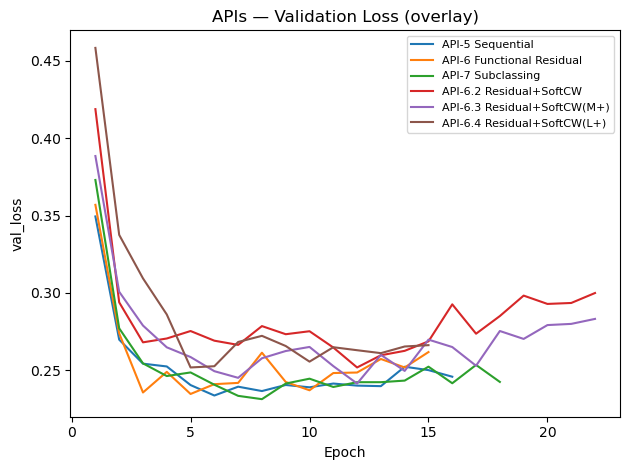

Guardado: figs_api/api__val_loss_overlay.png


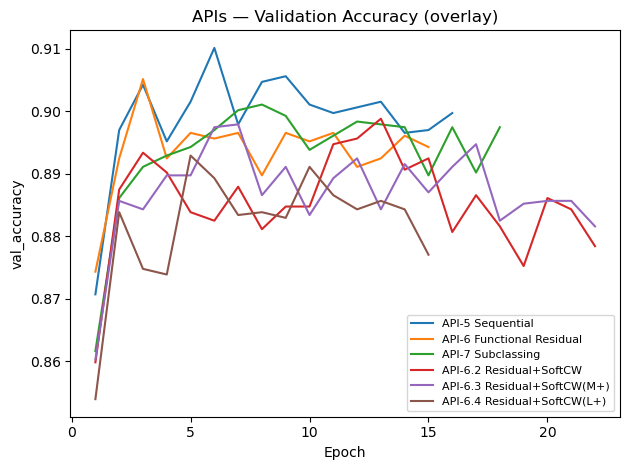

Guardado: figs_api/api__val_acc_overlay.png
[WARN] Nenhum history contém 'val_acc'.


In [24]:
import os, re
import numpy as np
import matplotlib.pyplot as plt

OUTDIR = "figs_api"
os.makedirs(OUTDIR, exist_ok=True)

def safe_name(s):
    s = s.strip().lower()
    s = re.sub(r"[^\w\-]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")

def show_history_keys(hist, name):
    if hist is None or not hasattr(hist, "history"):
        print(f"[WARN] {name}: history inválido/None")
        return
    print(f"{name} keys:", list(hist.history.keys()))

def overlay(histories, key, title, outname):
    plt.figure()
    added = 0

    for name, hist in histories.items():
        if hist is None or not hasattr(hist, "history"):
            continue
        h = hist.history
        if key not in h:
            continue
        y = np.array(h[key], dtype=float)
        x = np.arange(1, len(y) + 1)
        plt.plot(x, y, label=name)
        added += 1

    if added == 0:
        print(f"[WARN] Nenhum history contém '{key}'.")
        plt.close()
        return

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(key)
    plt.legend(fontsize=8)
    plt.tight_layout()
    path = os.path.join(OUTDIR, outname)
    plt.savefig(path, dpi=300)
    plt.show()
    plt.close()
    print("Guardado:", path)

# --- 1) Garante que os nomes correspondem aos teus objetos ---
api_histories = {
    "API-5 Sequential": hist5,
    "API-6 Functional Residual": hist6,
    "API-7 Subclassing": hist7,
    "API-6.2 Residual+SoftCW": hist62,
    "API-6.3 Residual+SoftCW(M+)": hist63,
    "API-6.4 Residual+SoftCW(L+)": hist64,
}

# --- 2) Diagnóstico rápido (para perceber por que não aparecia) ---
for n, h in api_histories.items():
    show_history_keys(h, n)

# --- 3) Overlays principais ---
overlay(api_histories, "val_loss", "APIs — Validation Loss (overlay)", "api__val_loss_overlay.png")

# val_accuracy pode não existir em todos: tenta primeiro val_accuracy, senão val_acc
overlay(api_histories, "val_accuracy", "APIs — Validation Accuracy (overlay)", "api__val_acc_overlay.png")
overlay(api_histories, "val_acc", "APIs — Validation Accuracy (overlay)", "api__val_acc_overlay_alt.png")


Epoch 1/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7115 - loss: 0.7875 - val_accuracy: 0.8798 - val_loss: 0.3465
Epoch 2/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.7859 - loss: 0.5322 - val_accuracy: 0.8907 - val_loss: 0.3088
Epoch 3/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.8140 - loss: 0.4687 - val_accuracy: 0.9020 - val_loss: 0.2774
Epoch 4/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.8224 - loss: 0.4370 - val_accuracy: 0.9025 - val_loss: 0.2657
Epoch 5/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.8357 - loss: 0.4122 - val_accuracy: 0.9052 - val_loss: 0.2594
Epoch 6/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.8382 - loss: 0.3953 - val_accuracy: 0.9011 - val_loss: 0.2650
Epoch 7/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.8466 - loss: 0.3847 - val_accuracy: 0.9070 - val_loss: 0.2557
Epoch 8/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.8510 - loss: 0.3

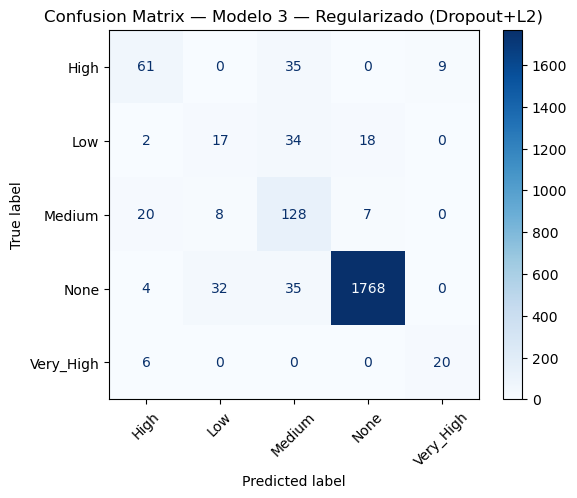

Epoch 1/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step - accuracy: 0.7426 - loss: 0.7026
Epoch 2/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.8084 - loss: 0.4770
Epoch 3/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - accuracy: 0.8300 - loss: 0.4165
Epoch 4/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.8472 - loss: 0.3851
Epoch 5/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - accuracy: 0.8554 - loss: 0.3637
Epoch 6/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.8582 - loss: 0.3516
Epoch 7/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - accuracy: 0.8633 - loss: 0.3414
Epoch 8/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.8659 - loss: 0.3372
Epoch 9/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.8665 - loss: 0.3288
Epoch 10/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - accuracy: 0.8719 - loss: 0.3204
Epoch 11/18
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.8760 - loss: 0.3162
Epoch 12/18
345/345 ━━━━━━━━━━

In [12]:
########################### MODELO 6 — MLP Regularizado (Dropout + L2) ###########################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

N_CLASSES = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

def eval_model(model, name):
    y_pred = model.predict(X_val, verbose=0).argmax(axis=1)
    print(f"\n=== {name} — VAL Report ===")
    print(classification_report(y_val_full, y_pred, target_names=le_full.classes_))

    cm = confusion_matrix(y_val_full, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)

    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print(f"Submissão pronta: {out_csv}")


model3 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(N_CLASSES, activation="softmax")
], name="mlp_regularizado_dropout_l2")

model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist3 = model3.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

eval_model(model3, "Modelo 3 — Regularizado (Dropout+L2)")

best_epochs_3 = len(hist3.history["loss"])

# treino final
model3_final = keras.models.clone_model(model3)
model3_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model3_final.fit(
    X_all, y_full,
    epochs=best_epochs_3,
    batch_size=32,
    verbose=1
)

make_submission(model3_final, "submission_modelo6_regularizado.csv")


Epoch 1/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6222 - loss: 1.0186 - val_accuracy: 0.8634 - val_loss: 0.4148
Epoch 2/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.7763 - loss: 0.6050 - val_accuracy: 0.8811 - val_loss: 0.3363
Epoch 3/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.7979 - loss: 0.5187 - val_accuracy: 0.8897 - val_loss: 0.3109
Epoch 4/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.8218 - loss: 0.4680 - val_accuracy: 0.8988 - val_loss: 0.2843
Epoch 5/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.8241 - loss: 0.4445 - val_accuracy: 0.8970 - val_loss: 0.2768
Epoch 6/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - accuracy: 0.8331 - loss: 0.4175 - val_accuracy: 0.8970 - val_loss: 0.2712
Epoch 7/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.8358 - loss: 0.4068 - val_accuracy: 0.9052 - val_loss: 0.2626
Epoch 8/120
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.8410 - loss: 0.3

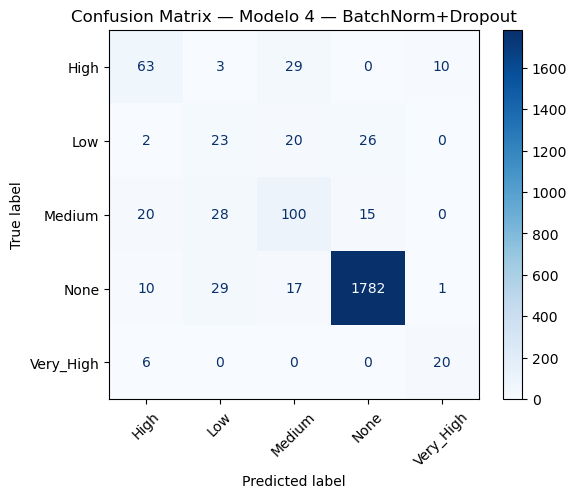

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - accuracy: 0.6538 - loss: 0.9775
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.7994 - loss: 0.5606
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.8214 - loss: 0.4695
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - accuracy: 0.8415 - loss: 0.4188
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.8380 - loss: 0.4087
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - accuracy: 0.8458 - loss: 0.3880
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.8490 - loss: 0.3729
Epoch 8/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8552 - loss: 0.3569
Epoch 9/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.8574 - loss: 0.3485
Epoch 10/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - accuracy: 0.8618 - loss: 0.3405
Epoch 11/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - accuracy: 0.8615 - loss: 0.3339
Epoch 12/20
345/345 ━━━━━━━━━━

In [13]:
############################## MODELO 7 — MLP com BatchNormalization + Dropout ##################################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

N_CLASSES = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

def eval_model(model, name):
    y_pred = model.predict(X_val, verbose=0).argmax(axis=1)
    print(f"\n=== {name} — VAL Report ===")
    print(classification_report(y_val_full, y_pred, target_names=le_full.classes_))

    cm = confusion_matrix(y_val_full, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)

    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print(f"Submissão pronta: {out_csv}")




model4 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(N_CLASSES, activation="softmax")
], name="mlp_batchnorm_dropout")

model4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist4 = model4.fit(
    X_train, y_train_full,
    validation_data=(X_val, y_val_full),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

eval_model(model4, "Modelo 4 — BatchNorm+Dropout")

best_epochs_4 = len(hist4.history["loss"])

# treino final
model4_final = keras.models.clone_model(model4)
model4_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model4_final.fit(
    X_all, y_full,
    epochs=best_epochs_4,
    batch_size=32,
    verbose=1
)

make_submission(model4_final, "submission_modelo7_batchnorm.csv")


Epoch 1/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accuracy: 0.9274 - loss: 0.1928 - val_accuracy: 0.9410 - val_loss: 0.1453
Epoch 2/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - accuracy: 0.9602 - loss: 0.1043 - val_accuracy: 0.9437 - val_loss: 0.1437
Epoch 3/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - accuracy: 0.9626 - loss: 0.0941 - val_accuracy: 0.9446 - val_loss: 0.1478
Epoch 4/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - accuracy: 0.9641 - loss: 0.0889 - val_accuracy: 0.9460 - val_loss: 0.1509
Epoch 5/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.9647 - loss: 0.0853 - val_accuracy: 0.9474 - val_loss: 0.1529
Epoch 6/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - accuracy: 0.9649 - loss: 0.0825 - val_accuracy: 0.9474 - val_loss: 0.1531
Epoch 7/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.9662 - loss: 0.0802 - val_accuracy: 0.9474 - val_loss: 0.1549
Epoch 8/80
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.9667 - loss: 0.0782 - 

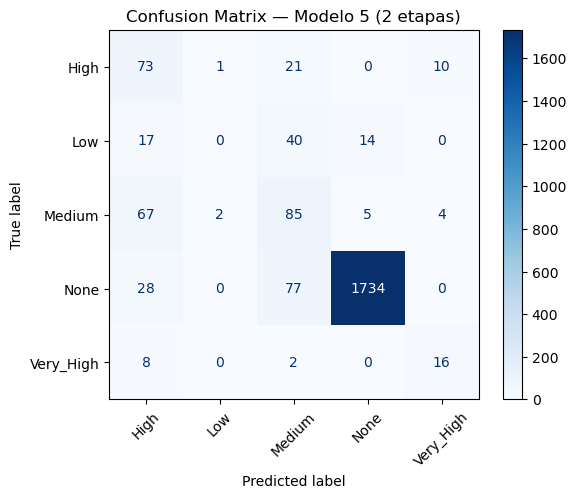

Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.9093 - loss: 0.2407
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.9592 - loss: 0.1088
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.9627 - loss: 0.0995
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.9649 - loss: 0.0939
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.9660 - loss: 0.0889
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - accuracy: 0.9668 - loss: 0.0847
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.9672 - loss: 0.0815
Epoch 8/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - accuracy: 0.9683 - loss: 0.0786
Epoch 9/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.9694 - loss: 0.0762
Epoch 10/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.9703 - loss: 0.0741
Epoch 1/8
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - accuracy: 0.4220 - loss: 1.2203 
Epoch 2/8
102/102 ━━━━━━━━━━━━━

In [14]:
############################ MODELO 8 — 2 Etapas (Binário + Energia 4 classes)#########################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

N_CLASSES = len(le_full.classes_)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

def eval_model(model, name):
    y_pred = model.predict(X_val, verbose=0).argmax(axis=1)
    print(f"\n=== {name} — VAL Report ===")
    print(classification_report(y_val_full, y_pred, target_names=le_full.classes_))

    cm = confusion_matrix(y_val_full, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

def make_submission(model, out_csv):
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)

    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print(f"Submissão pronta: {out_csv}")

# --- criar targets binários a partir do full (se não tiveres y_train_bin pronto) ---
# Isto assume que "None" é uma das classes em le_full.classes_
none_label = "None"
none_class_index = np.where(le_full.classes_ == none_label)[0][0]

y_train_bin = (y_train_full != none_class_index).astype(int)
y_val_bin   = (y_val_full   != none_class_index).astype(int)

# --- dataset só com energia (remover None) ---
mask_train_energy = (y_train_bin == 1)
mask_val_energy   = (y_val_bin == 1)

X_train_energy = X_train[mask_train_energy]
X_val_energy   = X_val[mask_val_energy]

y_train_energy_full = y_train_full[mask_train_energy]
y_val_energy_full   = y_val_full[mask_val_energy]

# mapear {Low,Medium,High,Very_High} para 0..3 (sem None)
energy_class_indices = [i for i, c in enumerate(le_full.classes_) if c != "None"]
map_full_to_energy = {full_i: new_i for new_i, full_i in enumerate(energy_class_indices)}

y_train_energy = np.array([map_full_to_energy[v] for v in y_train_energy_full], dtype=np.int32)
y_val_energy   = np.array([map_full_to_energy[v] for v in y_val_energy_full], dtype=np.int32)

N_ENERGY = len(energy_class_indices)

# ---------- Modelo 5A: Binário ----------
model5_bin = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(2, activation="softmax")
], name="mlp_binario_none_vs_energia")

model5_bin.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist5a = model5_bin.fit(
    X_train, y_train_bin,
    validation_data=(X_val, y_val_bin),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------- Modelo 5B: Energia 4-way ----------
model5_energy = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(N_ENERGY, activation="softmax")
], name="mlp_energia_4_classes")

model5_energy.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist5b = model5_energy.fit(
    X_train_energy, y_train_energy,
    validation_data=(X_val_energy, y_val_energy),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------- Avaliação 2 etapas no VAL (full 5 classes) ----------
# 1) prever binário
p_bin = model5_bin.predict(X_val, verbose=0).argmax(axis=1)

# 2) onde for energia, prever classe energia e remapear para full
p_full = np.full(shape=(len(X_val),), fill_value=none_class_index, dtype=np.int32)

idx_energy = np.where(p_bin == 1)[0]
p_energy = model5_energy.predict(X_val[idx_energy], verbose=0).argmax(axis=1)

# map inverso: energy 0..3 -> full index original
map_energy_to_full = {new_i: full_i for new_i, full_i in enumerate(energy_class_indices)}
p_full[idx_energy] = np.array([map_energy_to_full[v] for v in p_energy], dtype=np.int32)

print("\n=== Modelo 5 — 2 Etapas — VAL Report ===")
print(classification_report(y_val_full, p_full, target_names=le_full.classes_))

cm5 = confusion_matrix(y_val_full, p_full)
ConfusionMatrixDisplay(cm5, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Modelo 5 (2 etapas)")
plt.show()

best_epochs_5a = len(hist5a.history["loss"])
best_epochs_5b = len(hist5b.history["loss"])

# ---------- Treino FINAL (em TODO o treino) ----------
y_bin_all = (y_full != none_class_index).astype(int)

mask_all_energy = (y_bin_all == 1)
X_all_energy = X_all[mask_all_energy]
y_all_energy_full = y_full[mask_all_energy]
y_all_energy = np.array([map_full_to_energy[v] for v in y_all_energy_full], dtype=np.int32)

model5_bin_final = keras.models.clone_model(model5_bin)
model5_bin_final.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model5_bin_final.fit(X_all, y_bin_all, epochs=best_epochs_5a, batch_size=32, verbose=1)

model5_energy_final = keras.models.clone_model(model5_energy)
model5_energy_final.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model5_energy_final.fit(X_all_energy, y_all_energy, epochs=best_epochs_5b, batch_size=32, verbose=1)

# ---------- SUBMISSÃO (2 etapas) ----------
p_bin_test = model5_bin_final.predict(X_test, verbose=0).argmax(axis=1)

p_full_test = np.full(shape=(len(X_test),), fill_value=none_class_index, dtype=np.int32)
idx_energy_t = np.where(p_bin_test == 1)[0]

p_energy_test = model5_energy_final.predict(X_test[idx_energy_t], verbose=0).argmax(axis=1)
p_full_test[idx_energy_t] = np.array([map_energy_to_full[v] for v in p_energy_test], dtype=np.int32)

labels_pred5 = le_full.inverse_transform(p_full_test)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred5)

dummy["Result"] = labels_pred5
dummy.to_csv("submission_modelo8_2etapas.csv", index=False)
print("Submissão pronta: submission_modelo8_2etapas.csv")


(Dropout + L2)
Comportamento “tímido”
Continua a mandar Low / Medium → None
Regularização não resolve desbalanceamento

 (BatchNorm + Dropout)
Mais estável
Melhor que o 3
Mas não compete com Residual
Experiência válida, não finalista
(2 etapas)
Este é importante perceber por que falhou:
O modelo binário está a errar muito:
Energia → None
None → Energia
Quando o binário erra, não há recuperação possível
Resultado: macro-recall colapsa


Classes full: ['High', 'Low', 'Medium', 'None', 'Very_High']
Energy full indices: [0, 1, 2, 4]
N_ENERGY: 4
Epoch 1/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8878 - loss: 0.2677 - val_accuracy: 0.9365 - val_loss: 0.1597
Epoch 2/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.9518 - loss: 0.1288 - val_accuracy: 0.9415 - val_loss: 0.1380
Epoch 3/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.9569 - loss: 0.1129 - val_accuracy: 0.9492 - val_loss: 0.1253
Epoch 4/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - accuracy: 0.9586 - loss: 0.1045 - val_accuracy: 0.9501 - val_loss: 0.1258
Epoch 5/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.9624 - loss: 0.0973 - val_accuracy: 0.9505 - val_loss: 0.1268
Epoch 6/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - accuracy: 0.9636 - loss: 0.0927 - val_accuracy: 0.9501 - val_loss: 0.1253
Epoch 7/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.9648 - loss: 0.0878 - val_accuracy: 0.94

/opt/anaconda3/envs/lcd_scaa/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/lcd_scaa/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/lcd_scaa/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

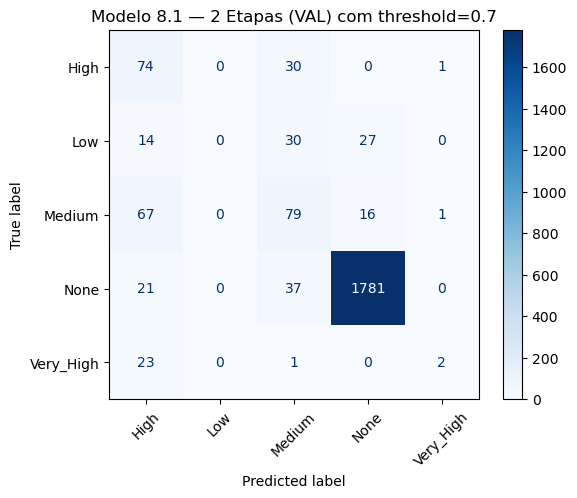

Best epochs bin: 11 Best epochs energy: 8
Epoch 1/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.8848 - loss: 0.2646
Epoch 2/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - accuracy: 0.9514 - loss: 0.1262
Epoch 3/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step - accuracy: 0.9584 - loss: 0.1102
Epoch 4/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.9606 - loss: 0.1029
Epoch 5/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.9619 - loss: 0.0987
Epoch 6/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.9622 - loss: 0.0954
Epoch 7/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - accuracy: 0.9635 - loss: 0.0912
Epoch 8/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - accuracy: 0.9653 - loss: 0.0876
Epoch 9/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.9654 - loss: 0.0850
Epoch 10/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.9662 - loss: 0.0829
Epoch 11/11
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.9670 - l

In [15]:
############################ MODELO 8.1 — 2 Etapas + Threshold Tuning (Binário -> Energia 4-way) ############################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# -------------------------
# Helpers
# -------------------------
def make_submission_from_full_pred(p_full_test, out_csv):
    labels_pred = le_full.inverse_transform(p_full_test)
    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

def eval_full(y_true, y_pred_full, title):
    print("\n" + title)
    print("acc:", accuracy_score(y_true, y_pred_full), "macroF1:", f1_score(y_true, y_pred_full, average="macro"))
    print(classification_report(y_true, y_pred_full, target_names=le_full.classes_))
    cm = confusion_matrix(y_true, y_pred_full)
    ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

# -------------------------
# Setup classes / mappings
# -------------------------
none_label = "None"
assert none_label in le_full.classes_, "A classe 'None' não existe em le_full.classes_"
none_class_index = int(np.where(le_full.classes_ == none_label)[0][0])

# binários (0=None, 1=energia)
y_train_bin = (y_train_full != none_class_index).astype(int)
y_val_bin   = (y_val_full   != none_class_index).astype(int)

# subset energia (remover None)
mask_train_energy = (y_train_bin == 1)
mask_val_energy   = (y_val_bin == 1)

X_train_energy = X_train[mask_train_energy]
X_val_energy   = X_val[mask_val_energy]

y_train_energy_full = y_train_full[mask_train_energy]
y_val_energy_full   = y_val_full[mask_val_energy]

# map full->energy (0..3 sem None)
energy_class_indices = [i for i, c in enumerate(le_full.classes_) if c != "None"]
map_full_to_energy = {full_i: new_i for new_i, full_i in enumerate(energy_class_indices)}
map_energy_to_full = {new_i: full_i for new_i, full_i in enumerate(energy_class_indices)}

y_train_energy = np.array([map_full_to_energy[v] for v in y_train_energy_full], dtype=np.int32)
y_val_energy   = np.array([map_full_to_energy[v] for v in y_val_energy_full], dtype=np.int32)

N_ENERGY = len(energy_class_indices)

print("Classes full:", list(le_full.classes_))
print("Energy full indices:", energy_class_indices)
print("N_ENERGY:", N_ENERGY)

# -------------------------
# Models
# -------------------------
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

# Binário: (None vs Energia)
model_bin = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(1, activation="sigmoid")   # <- melhor para binário
], name="model8_1_bin_sigmoid")

model_bin.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

hist_bin = model_bin.fit(
    X_train, y_train_bin,
    validation_data=(X_val, y_val_bin),
    epochs=120,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Energia 4-way (só exemplos != None)
model_energy = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(N_ENERGY, activation="softmax")
], name="model8_1_energy_4way")

model_energy.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_energy = model_energy.fit(
    X_train_energy, y_train_energy,
    validation_data=(X_val_energy, y_val_energy),
    epochs=120,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------
# Threshold tuning no VAL
# -------------------------
# probabilidade de energia (sigmoid)
p_energy_prob_val = model_bin.predict(X_val, verbose=0).reshape(-1)

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]
scores = []

for t in thresholds:
    p_bin = (p_energy_prob_val >= t).astype(int)

    p_full = np.full((len(X_val),), none_class_index, dtype=np.int32)
    idx_energy = np.where(p_bin == 1)[0]

    if len(idx_energy) > 0:
        p_energy = model_energy.predict(X_val[idx_energy], verbose=0).argmax(axis=1)
        p_full[idx_energy] = np.array([map_energy_to_full[v] for v in p_energy], dtype=np.int32)

    acc = accuracy_score(y_val_full, p_full)
    mf1 = f1_score(y_val_full, p_full, average="macro")
    scores.append((t, acc, mf1))
    print(f"t={t:.2f}  acc={acc:.4f}  macroF1={mf1:.4f}  energia_preds={len(idx_energy)}")

best_t, best_acc, best_mf1 = sorted(scores, key=lambda x: (x[2], x[1]), reverse=True)[0]
print("\nBEST threshold:", best_t, "acc:", best_acc, "macroF1:", best_mf1)

# Mostrar relatório/CM do melhor threshold
p_bin_best = (p_energy_prob_val >= best_t).astype(int)
p_full_best = np.full((len(X_val),), none_class_index, dtype=np.int32)
idx_energy_best = np.where(p_bin_best == 1)[0]
if len(idx_energy_best) > 0:
    p_energy_best = model_energy.predict(X_val[idx_energy_best], verbose=0).argmax(axis=1)
    p_full_best[idx_energy_best] = np.array([map_energy_to_full[v] for v in p_energy_best], dtype=np.int32)

eval_full(y_val_full, p_full_best, f"Modelo 8.1 — 2 Etapas (VAL) com threshold={best_t}")

best_epochs_bin = len(hist_bin.history["loss"])
best_epochs_energy = len(hist_energy.history["loss"])
print("Best epochs bin:", best_epochs_bin, "Best epochs energy:", best_epochs_energy)

# -------------------------
# Treino FINAL (ALL) + Submissão (usa best_t)
# -------------------------
y_bin_all = (y_full != none_class_index).astype(int)
mask_all_energy = (y_bin_all == 1)
X_all_energy = X_all[mask_all_energy]
y_all_energy_full = y_full[mask_all_energy]
y_all_energy = np.array([map_full_to_energy[v] for v in y_all_energy_full], dtype=np.int32)

model_bin_final = keras.models.clone_model(model_bin)
model_bin_final.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
model_bin_final.fit(X_all, y_bin_all, epochs=best_epochs_bin, batch_size=64, verbose=1)

model_energy_final = keras.models.clone_model(model_energy)
model_energy_final.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_energy_final.fit(X_all_energy, y_all_energy, epochs=best_epochs_energy, batch_size=64, verbose=1)

# Prever TESTE com threshold
p_energy_prob_test = model_bin_final.predict(X_test, verbose=0).reshape(-1)
p_bin_test = (p_energy_prob_test >= best_t).astype(int)

p_full_test = np.full((len(X_test),), none_class_index, dtype=np.int32)
idx_energy_t = np.where(p_bin_test == 1)[0]
if len(idx_energy_t) > 0:
    p_energy_test = model_energy_final.predict(X_test[idx_energy_t], verbose=0).argmax(axis=1)
    p_full_test[idx_energy_t] = np.array([map_energy_to_full[v] for v in p_energy_test], dtype=np.int32)

make_submission_from_full_pred(p_full_test, "submission_modelo8_1_2etapas_threshold.csv")


está a colapsar para “Medium” (a classe mais frequente dentro do subset energia).

In [25]:
############################# MODELO 9 - Ambiente Gymnasium + Agente DQN simples (Keras) ##############
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class EnergyInjectionEnv(gym.Env):
    """
    Ambiente RL para classificação sequencial:
    obs = features (float32)
    action = classe (0..4)
    reward = +1 acerto, negativo erro (com pesos opcionais)
    """

    metadata = {"render_modes": []}

    def __init__(self, X, y, episode_len=24, class_reward=None):
        super().__init__()
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int32)
        self.n = len(X)
        self.episode_len = episode_len
        self.class_reward = class_reward  # dict: {class_id: weight}

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.X.shape[1],), dtype=np.float32
        )
        self.action_space = spaces.Discrete(int(np.max(self.y)) + 1)

        self._t = 0
        self._start = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # escolhe início aleatório garantindo episódio inteiro
        self._start = self.np_random.integers(0, self.n - self.episode_len)
        self._t = 0
        obs = self.X[self._start]
        return obs, {}

    def step(self, action):
        idx = self._start + self._t
        true = int(self.y[idx])

        # reward básico
        correct = (int(action) == true)
        r = 1.0 if correct else -1.0

        # reward shaping por classe (opcional)
        if self.class_reward is not None:
            r *= float(self.class_reward.get(true, 1.0))

        self._t += 1
        done = (self._t >= self.episode_len)

        next_idx = self._start + self._t
        obs = self.X[next_idx] if not done else np.zeros_like(self.X[0], dtype=np.float32)

        return obs, r, done, False, {"true": true, "pred": int(action)}
    
    
def play_random_episodes(env, n_episodes=200):
    total = 0.0
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_r = 0.0
        while not done:
            a = env.action_space.sample()
            obs, r, done, _, _ = env.step(a)
            ep_r += r
        total += ep_r
    return total / n_episodes

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
from collections import deque

def build_qnet(n_features, n_actions):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_actions)  # Q-values
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

def dqn_train(env, n_actions, episodes=500, gamma=0.99,
              eps_start=1.0, eps_end=0.05, eps_decay=0.995,
              batch_size=64, buffer_size=20000, target_sync=20):

    qnet = build_qnet(env.observation_space.shape[0], n_actions)
    target = build_qnet(env.observation_space.shape[0], n_actions)
    target.set_weights(qnet.get_weights())

    replay = deque(maxlen=buffer_size)
    eps = eps_start

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # epsilon-greedy
            if random.random() < eps:
                a = env.action_space.sample()
            else:
                q = qnet.predict(s[None, :], verbose=0)[0]
                a = int(np.argmax(q))

            s2, r, done, _, _ = env.step(a)
            ep_return += r
            replay.append((s, a, r, s2, done))
            s = s2

            # treino
            if len(replay) >= batch_size:
                batch = random.sample(replay, batch_size)
                S = np.array([b[0] for b in batch], dtype=np.float32)
                A = np.array([b[1] for b in batch], dtype=np.int32)
                R = np.array([b[2] for b in batch], dtype=np.float32)
                S2 = np.array([b[3] for b in batch], dtype=np.float32)
                D = np.array([b[4] for b in batch], dtype=np.float32)

                q_vals = qnet.predict(S, verbose=0)
                q_next = target.predict(S2, verbose=0).max(axis=1)

                y = q_vals.copy()
                y[np.arange(batch_size), A] = R + (1.0 - D) * gamma * q_next

                qnet.train_on_batch(S, y)

        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % target_sync == 0:
            target.set_weights(qnet.get_weights())

        if (ep + 1) % 50 == 0:
            print(f"EP {ep+1}/{episodes} | return={ep_return:.1f} | eps={eps:.3f}")

    return qnet

def predict_with_qnet(qnet, X):
    q = qnet.predict(X.astype(np.float32), verbose=0)
    return q.argmax(axis=1)

# Exemplo de reward shaping (podes reforçar classes raras)
# Ajusta conforme as tuas contagens: dar mais peso a Very_High/Low etc.
class_reward = {0: 1.2, 1: 1.3, 2: 1.0, 3: 0.6, 4: 1.5}  # exemplo

env = EnergyInjectionEnv(X_all, y_full, episode_len=24, class_reward=class_reward)

print("Random baseline avg return:", play_random_episodes(env, 200))

qnet = dqn_train(env, n_actions=len(le_full.classes_), episodes=500)

# Prever no teste e gerar submissão
y_test_pred = predict_with_qnet(qnet, X_test)
labels_pred = le_full.inverse_transform(y_test_pred)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred)
dummy["Result"] = labels_pred
dummy.to_csv("submission_9rl_dqn.csv", index=False)
print("Submissão pronta: submission_9rl_dqn.csv")


Random baseline avg return: -11.553000000000003
EP 50/500 | return=-4.8 | eps=0.778
EP 100/500 | return=-0.2 | eps=0.606
EP 150/500 | return=3.6 | eps=0.471
EP 200/500 | return=0.4 | eps=0.367
EP 250/500 | return=-1.0 | eps=0.286
EP 300/500 | return=1.9 | eps=0.222
EP 350/500 | return=0.4 | eps=0.173
EP 400/500 | return=-6.8 | eps=0.135
EP 450/500 | return=2.6 | eps=0.105
EP 500/500 | return=-10.7 | eps=0.082
Submissão pronta: submission_9rl_dqn.csv


X_seq_all: (11016, 24, 91) y_seq_all: (11016,)
X_seq_test: (2256, 24, 91)
Train seq: (8812, 24, 91) Val seq: (2204, 24, 91)
EP 25/300 | return=-25.8 | eps=0.882
EP 50/300 | return=-21.3 | eps=0.778
EP 75/300 | return=-16.0 | eps=0.687
EP 100/300 | return=-25.0 | eps=0.606
EP 125/300 | return=-2.1 | eps=0.534
EP 150/300 | return=23.2 | eps=0.471
EP 175/300 | return=14.0 | eps=0.416
EP 200/300 | return=23.1 | eps=0.367
EP 225/300 | return=15.9 | eps=0.324
EP 250/300 | return=40.2 | eps=0.286
EP 275/300 | return=39.2 | eps=0.252
EP 300/300 | return=42.9 | eps=0.222

=== MODELO 9.1 (RL DQN CNN1D) — VAL ===
acc: 0.8189655172413793 macroF1: 0.44389981481356766
              precision    recall  f1-score   support

        High       0.30      0.63      0.41       105
         Low       0.11      0.15      0.13        71
      Medium       0.36      0.24      0.29       163
        None       0.97      0.91      0.94      1839
   Very_High       0.32      0.77      0.45        26

    accurac

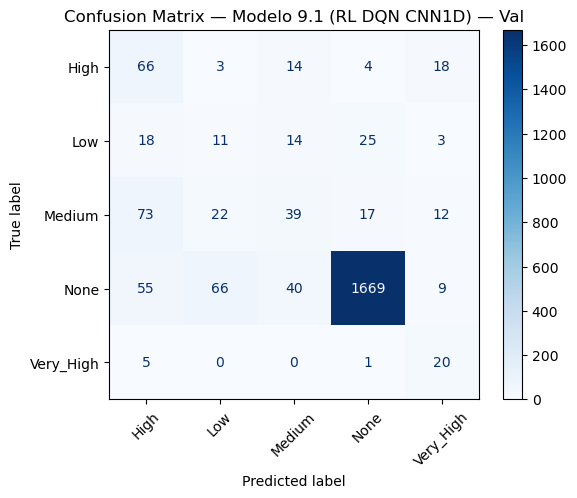

Submissão pronta: submission_modelo9_1_rl_dqn_cnn1d.csv


In [26]:
############################ MODELO 9.1 — RL DQN com ESTADO SEQUENCIAL (WINDOW=24) + CNN1D ############################


import numpy as np
import pandas as pd
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from collections import deque
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

WINDOW = 24
N_CLASSES = len(le_full.classes_)

# =========================================================
# 1) Criar SEQUÊNCIAS (padded) para ter previsão em TODAS as horas
# =========================================================
def make_seq_padded(X, window=24):
    """
    Retorna X_seq com shape (n_samples, window, n_features)
    Para i < window-1, faz padding repetindo a 1ª linha (simples e estável).
    """
    X = X.astype(np.float32)
    n, d = X.shape
    X_seq = np.zeros((n, window, d), dtype=np.float32)
    for i in range(n):
        start = i - window + 1
        if start < 0:
            pad = np.repeat(X[0:1], -start, axis=0)
            chunk = X[0:i+1]
            win = np.vstack([pad, chunk])
        else:
            win = X[start:i+1]
        X_seq[i] = win
    return X_seq

X_seq_all = make_seq_padded(X_all, WINDOW)     # (n_train, 24, n_features)
y_seq_all = y_full.astype(np.int32)            # label do instante atual (mesmo índice)

X_seq_test = make_seq_padded(X_test, WINDOW)   # (n_test, 24, n_features)

print("X_seq_all:", X_seq_all.shape, "y_seq_all:", y_seq_all.shape)
print("X_seq_test:", X_seq_test.shape)

# =========================================================
# 2) Split temporal (80/20) em sequências
# =========================================================
cut = int(len(X_seq_all) * 0.8)
X_train_seq, X_val_seq = X_seq_all[:cut], X_seq_all[cut:]
y_train_seq, y_val_seq = y_seq_all[:cut], y_seq_all[cut:]

print("Train seq:", X_train_seq.shape, "Val seq:", X_val_seq.shape)

# =========================================================
# 3) Ambiente RL (episódios contíguos)
# =========================================================
class SeqEnv:
    """
    Env minimalista:
    - state = janela (24, n_features)
    - action = classe 0..4
    - reward = +w se acerta, -w se erra (w depende da classe verdadeira)
    """
    def __init__(self, X_seq, y, episode_len=96, class_reward=None):
        self.X = X_seq.astype(np.float32)
        self.y = y.astype(np.int32)
        self.n = len(y)
        self.episode_len = episode_len
        self.class_reward = class_reward or {c: 1.0 for c in np.unique(self.y)}
        self.t = 0
        self.start = 0

    def reset(self):
        # escolher início aleatório garantindo episódio inteiro
        self.start = np.random.randint(0, self.n - self.episode_len - 1)
        self.t = 0
        return self.X[self.start], {}

    def step(self, action):
        idx = self.start + self.t
        true = int(self.y[idx])
        w = float(self.class_reward.get(true, 1.0))

        r = (1.0 if int(action) == true else -1.0) * w

        self.t += 1
        done = (self.t >= self.episode_len)

        obs = self.X[self.start + self.t] if not done else np.zeros_like(self.X[0])
        return obs, r, done, {"true": true, "pred": int(action)}

# Reward shaping leve (não inventar muito)
# Ajusta se quiseres: dar mais peso às raras
class_reward = {0: 1.2, 1: 1.4, 2: 1.0, 3: 0.7, 4: 1.6}  # High, Low, Medium, None, Very_High (pela tua ordem)
env = SeqEnv(X_train_seq, y_train_seq, episode_len=96, class_reward=class_reward)

# =========================================================
# 4) DQN com CNN1D (Q(s,a))
# =========================================================
def build_qnet_cnn(window, n_features, n_actions):
    inp = keras.Input(shape=(window, n_features), name="state")
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(inp)
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(n_actions, name="q_values")(x)
    model = keras.Model(inp, out, name="qnet_cnn1d")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

qnet = build_qnet_cnn(WINDOW, X_train_seq.shape[2], N_CLASSES)
target = build_qnet_cnn(WINDOW, X_train_seq.shape[2], N_CLASSES)
target.set_weights(qnet.get_weights())

# =========================================================
# 5) Treino DQN
# =========================================================
def dqn_train_seq(env, qnet, target, episodes=300, gamma=0.99,
                  eps_start=1.0, eps_end=0.05, eps_decay=0.995,
                  batch_size=64, buffer_size=50000, target_sync=20):

    replay = deque(maxlen=buffer_size)
    eps = eps_start

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # epsilon-greedy
            if random.random() < eps:
                a = random.randint(0, N_CLASSES - 1)
            else:
                q = qnet.predict(s[None, ...], verbose=0)[0]
                a = int(np.argmax(q))

            s2, r, done, info = env.step(a)
            ep_return += r
            replay.append((s, a, r, s2, float(done)))
            s = s2

            # treino
            if len(replay) >= batch_size:
                batch = random.sample(replay, batch_size)
                S  = np.stack([b[0] for b in batch]).astype(np.float32)   # (B, 24, F)
                A  = np.array([b[1] for b in batch], dtype=np.int32)
                R  = np.array([b[2] for b in batch], dtype=np.float32)
                S2 = np.stack([b[3] for b in batch]).astype(np.float32)
                D  = np.array([b[4] for b in batch], dtype=np.float32)

                q_vals = qnet.predict(S, verbose=0)                      # (B, A)
                q_next = target.predict(S2, verbose=0).max(axis=1)       # (B,)

                y = q_vals.copy()
                y[np.arange(batch_size), A] = R + (1.0 - D) * gamma * q_next

                qnet.train_on_batch(S, y)

        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % target_sync == 0:
            target.set_weights(qnet.get_weights())

        if (ep + 1) % 25 == 0:
            print(f"EP {ep+1}/{episodes} | return={ep_return:.1f} | eps={eps:.3f}")

    return qnet

qnet = dqn_train_seq(env, qnet, target, episodes=300)

# =========================================================
# 6) Avaliar no VAL (greedy)
# =========================================================
q_val = qnet.predict(X_val_seq, verbose=0)
y_val_pred = q_val.argmax(axis=1)

print("\n=== MODELO 9.1 (RL DQN CNN1D) — VAL ===")
print("acc:", accuracy_score(y_val_seq, y_val_pred), "macroF1:", f1_score(y_val_seq, y_val_pred, average="macro"))
print(classification_report(y_val_seq, y_val_pred, target_names=le_full.classes_))

cm = confusion_matrix(y_val_seq, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Modelo 9.1 (RL DQN CNN1D) — Val")
plt.show()

# =========================================================
# 7) Prever TESTE + Submissão
# =========================================================
q_test = qnet.predict(X_seq_test, verbose=0)
y_test_pred = q_test.argmax(axis=1)
labels_pred = le_full.inverse_transform(y_test_pred)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
dummy["Result"] = labels_pred
dummy.to_csv("submission_modelo9_1_rl_dqn_cnn1d.csv", index=False)
print("Submissão pronta: submission_modelo9_1_rl_dqn_cnn1d.csv")


O agente aprendeu padrões temporais reais (24h)
O retorno por episódio subiu consistentemente
Logo: o ambiente e a recompensa estavam bem definidos

[RL-9] EP 50/500 | return=-8.0 | eps=0.778
[RL-9] EP 100/500 | return=-6.0 | eps=0.606
[RL-9] EP 150/500 | return=-2.0 | eps=0.471
[RL-9] EP 200/500 | return=4.0 | eps=0.367
[RL-9] EP 250/500 | return=2.0 | eps=0.286
[RL-9] EP 300/500 | return=2.0 | eps=0.222
[RL-9] EP 350/500 | return=10.0 | eps=0.173
[RL-9] EP 400/500 | return=-2.0 | eps=0.135
[RL-9] EP 450/500 | return=8.0 | eps=0.105
[RL-9] EP 500/500 | return=-6.0 | eps=0.082

RL-9 DQN (instant/tabular) — VAL
              precision    recall  f1-score   support

        High       0.18      0.35      0.24       105
         Low       0.08      0.32      0.12        71
      Medium       0.14      0.11      0.12       163
        None       0.98      0.67      0.80      1839
   Very_High       0.04      0.46      0.07        26

    accuracy                           0.60      2204
   macro avg       0.28      0.38      0.27      2204
weighted avg       0.84      0.60      0.69      2204



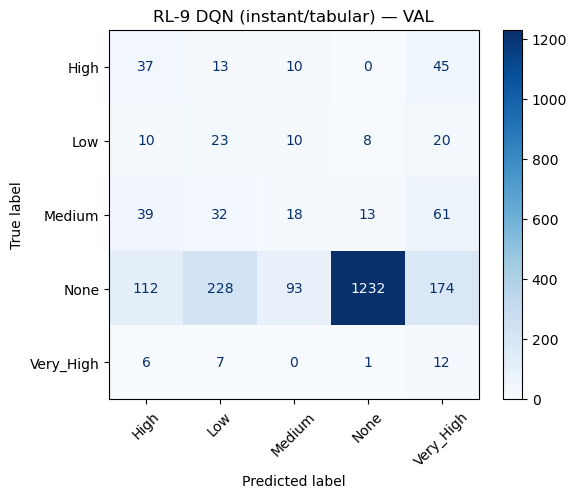

[RL-9.1] EP 25/300 | return=-42.0 | eps=0.882
[RL-9.1] EP 50/300 | return=-26.0 | eps=0.778
[RL-9.1] EP 75/300 | return=-8.0 | eps=0.687
[RL-9.1] EP 100/300 | return=-20.0 | eps=0.606
[RL-9.1] EP 125/300 | return=6.0 | eps=0.534
[RL-9.1] EP 150/300 | return=10.0 | eps=0.471
[RL-9.1] EP 175/300 | return=4.0 | eps=0.416
[RL-9.1] EP 200/300 | return=30.0 | eps=0.367
[RL-9.1] EP 225/300 | return=18.0 | eps=0.324
[RL-9.1] EP 250/300 | return=44.0 | eps=0.286
[RL-9.1] EP 275/300 | return=28.0 | eps=0.252
[RL-9.1] EP 300/300 | return=44.0 | eps=0.222

RL-9.1 DQN (window=24 + CNN1D) — VAL
              precision    recall  f1-score   support

        High       0.38      0.56      0.45       105
         Low       0.24      0.14      0.18        71
      Medium       0.37      0.44      0.40       163
        None       0.96      0.93      0.95      1839
   Very_High       0.47      0.58      0.52        26

    accuracy                           0.85      2204
   macro avg       0.48      0.5

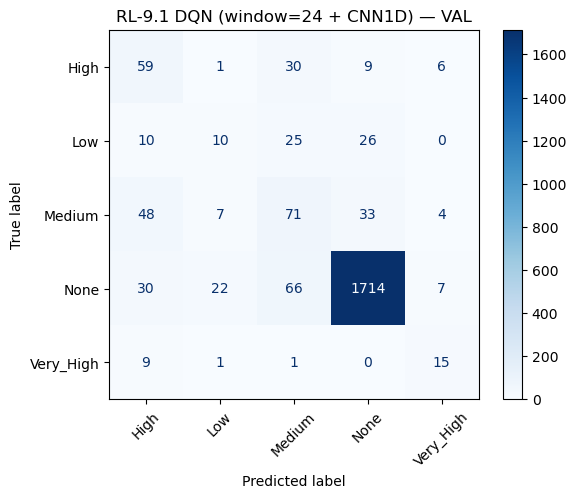


Resumo RL (ordenado por f1_macro):
                            model  accuracy  f1_macro  f1_weighted  \
0  RL-9.1 DQN (window=24 + CNN1D)  0.848004  0.498699     0.852811   
1      RL-9 DQN (instant/tabular)  0.599819  0.270514     0.689973   

   precision_macro  recall_macro  
0         0.484115      0.529457  
1         0.283120      0.383644  
✅ Guardado: rl_metrics_summary.csv


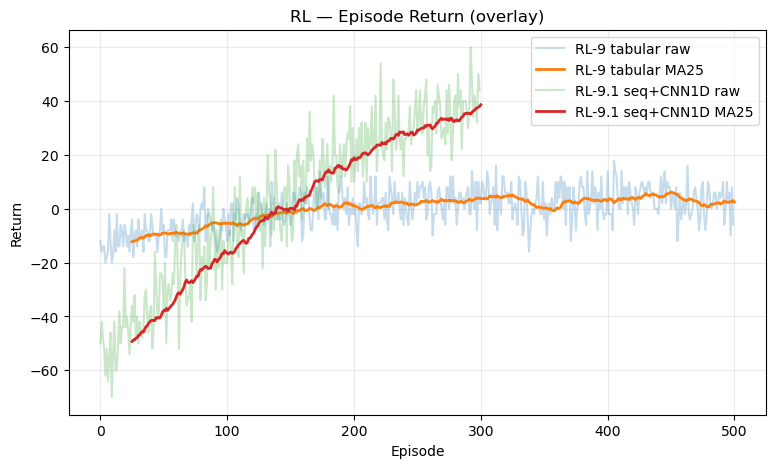

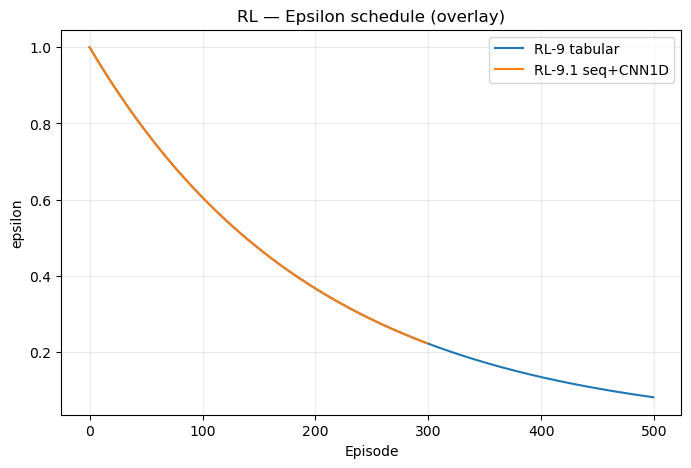

✅ Guardado: rl_returns_overlay.png e rl_eps_overlay.png


In [32]:
# ============================================================
# RL — TREINO + LOGS + MÉTRICAS (RL-9 e RL-9.1) + OVERLAYS
# O que vais mudar:
# 1) Usar as funções *_with_logs (devolvem qnet, returns, eps)
# 2) Guardar modelos com nomes diferentes: qnet9 e qnet91
# 3) Criar X_val_seq e y_val_seq (para RL-9.1) e manter X_val/y_val_full (RL-9)
# 4) No fim: gerar métricas + CMs + gráficos overlay (returns/eps)
# ============================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from collections import deque
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ------------------------------------------------------------
# 0) HELPERS — métricas, CM e plots
# ------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def show_report_cm(title, y_true, y_pred, label_names):
    print("\n" + title)
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

def moving_avg(x, w=25):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

def plot_overlay_returns(returns_dict, smooth_w=25, save_path=None):
    plt.figure(figsize=(9,5))
    for name, ret in returns_dict.items():
        ret = np.asarray(ret, dtype=float)
        plt.plot(ret, alpha=0.25, label=f"{name} raw")
        sm = moving_avg(ret, w=smooth_w)
        plt.plot(np.arange(len(sm)) + smooth_w, sm, linewidth=2.0, label=f"{name} MA{smooth_w}")
    plt.title("RL — Episode Return (overlay)")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True, alpha=0.25)
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_overlay_eps(eps_dict, save_path=None):
    plt.figure(figsize=(8,5))
    for name, eps in eps_dict.items():
        eps = np.asarray(eps, dtype=float)
        plt.plot(eps, label=name)
    plt.title("RL — Epsilon schedule (overlay)")
    plt.xlabel("Episode")
    plt.ylabel("epsilon")
    plt.legend()
    plt.grid(True, alpha=0.25)
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# 1) RL-9 (TABULAR) — ENV + QNET + TREINO COM LOGS
# ------------------------------------------------------------
# >>>> ALTERAÇÃO QUE TENS DE FAZER:
# - NÃO uses qnet = dqn_train(...)
# - usa: qnet9, returns_9, eps_9 = dqn_train_tabular_with_logs(...)
# - e avalia com X_val / y_val_full

import gymnasium as gym
from gymnasium import spaces

class EnergyInjectionEnv(gym.Env):
    """
    Env tabular:
    obs = (n_features,)
    action = classe 0..4
    reward = +1/-1 (com peso por classe opcional)
    """
    metadata = {"render_modes": []}

    def __init__(self, X, y, episode_len=24, class_reward=None):
        super().__init__()
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int32)
        self.n = len(self.X)
        self.episode_len = episode_len
        self.class_reward = class_reward
        self.n_actions = int(np.max(self.y)) + 1

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.X.shape[1],), dtype=np.float32
        )
        self.action_space = spaces.Discrete(self.n_actions)

        self._t = 0
        self._start = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._start = self.np_random.integers(0, self.n - self.episode_len)
        self._t = 0
        return self.X[self._start], {}

    def step(self, action):
        idx = self._start + self._t
        true = int(self.y[idx])

        correct = (int(action) == true)
        r = 1.0 if correct else -1.0

        if self.class_reward is not None:
            r *= float(self.class_reward.get(true, 1.0))

        self._t += 1
        done = (self._t >= self.episode_len)

        next_idx = self._start + self._t
        obs = self.X[next_idx] if not done else np.zeros_like(self.X[0], dtype=np.float32)

        return obs, r, done, False, {"true": true, "pred": int(action)}

def build_qnet_tabular(n_features, n_actions):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_actions)  # Q-values
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

def dqn_train_tabular_with_logs(env, episodes=500, gamma=0.99,
                               eps_start=1.0, eps_end=0.05, eps_decay=0.995,
                               batch_size=64, buffer_size=20000, target_sync=20):

    n_actions = env.n_actions
    qnet = build_qnet_tabular(env.observation_space.shape[0], n_actions)
    target = build_qnet_tabular(env.observation_space.shape[0], n_actions)
    target.set_weights(qnet.get_weights())

    replay = deque(maxlen=buffer_size)
    eps = eps_start

    returns = []
    eps_list = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            if random.random() < eps:
                a = env.action_space.sample()
            else:
                q = qnet.predict(s[None, :], verbose=0)[0]
                a = int(np.argmax(q))

            s2, r, done, _, _ = env.step(a)
            ep_return += r
            replay.append((s, a, r, s2, float(done)))
            s = s2

            if len(replay) >= batch_size:
                batch = random.sample(replay, batch_size)
                S  = np.array([b[0] for b in batch], dtype=np.float32)
                A  = np.array([b[1] for b in batch], dtype=np.int32)
                R  = np.array([b[2] for b in batch], dtype=np.float32)
                S2 = np.array([b[3] for b in batch], dtype=np.float32)
                D  = np.array([b[4] for b in batch], dtype=np.float32)

                q_vals = qnet.predict(S, verbose=0)
                q_next = target.predict(S2, verbose=0).max(axis=1)

                y = q_vals.copy()
                y[np.arange(batch_size), A] = R + (1.0 - D) * gamma * q_next
                qnet.train_on_batch(S, y)

        returns.append(ep_return)
        eps_list.append(eps)

        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % target_sync == 0:
            target.set_weights(qnet.get_weights())

        if (ep + 1) % 50 == 0:
            print(f"[RL-9] EP {ep+1}/{episodes} | return={ep_return:.1f} | eps={eps:.3f}")

    return qnet, returns, eps_list


# ------------------------------------------------------------
# 2) RL-9.1 (SEQUENCIAL window=24 + CNN1D) — SEQ + ENV + TREINO COM LOGS
# ------------------------------------------------------------
# >>>> ALTERAÇÃO QUE TENS DE FAZER:
# - garantir X_seq_all / X_val_seq / y_val_seq
# - NÃO uses qnet = dqn_train_seq(...)
# - usa: qnet91, returns_91, eps_91 = dqn_train_seq_with_logs(...)

WINDOW = 24

def make_seq_padded(X, window=24):
    X = X.astype(np.float32)
    n, d = X.shape
    X_seq = np.zeros((n, window, d), dtype=np.float32)
    for i in range(n):
        start = i - window + 1
        if start < 0:
            pad = np.repeat(X[0:1], -start, axis=0)
            chunk = X[0:i+1]
            win = np.vstack([pad, chunk])
        else:
            win = X[start:i+1]
        X_seq[i] = win
    return X_seq

class SeqEnv:
    """
    Env sequencial:
    state = (window, n_features)
    action = classe
    reward = +w/-w
    """
    def __init__(self, X_seq, y, episode_len=96, class_reward=None):
        self.X = X_seq.astype(np.float32)
        self.y = y.astype(np.int32)
        self.n = len(self.y)
        self.episode_len = episode_len
        self.class_reward = class_reward or {c: 1.0 for c in np.unique(self.y)}
        self.n_actions = int(np.max(self.y)) + 1
        self.t = 0
        self.start = 0

    def reset(self):
        self.start = np.random.randint(0, self.n - self.episode_len - 1)
        self.t = 0
        return self.X[self.start], {}

    def step(self, action):
        idx = self.start + self.t
        true = int(self.y[idx])
        w = float(self.class_reward.get(true, 1.0))
        r = (1.0 if int(action) == true else -1.0) * w

        self.t += 1
        done = (self.t >= self.episode_len)
        obs = self.X[self.start + self.t] if not done else np.zeros_like(self.X[0])
        return obs, r, done, {"true": true, "pred": int(action)}

def build_qnet_cnn(window, n_features, n_actions):
    inp = keras.Input(shape=(window, n_features), name="state")
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(inp)
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(n_actions, name="q_values")(x)
    model = keras.Model(inp, out, name="qnet_cnn1d")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

def dqn_train_seq_with_logs(env, qnet, target, episodes=300, gamma=0.99,
                            eps_start=1.0, eps_end=0.05, eps_decay=0.995,
                            batch_size=64, buffer_size=50000, target_sync=20):

    replay = deque(maxlen=buffer_size)
    eps = eps_start

    returns = []
    eps_list = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            if random.random() < eps:
                a = random.randint(0, env.n_actions - 1)
            else:
                q = qnet.predict(s[None, ...], verbose=0)[0]
                a = int(np.argmax(q))

            s2, r, done, info = env.step(a)
            ep_return += r
            replay.append((s, a, r, s2, float(done)))
            s = s2

            if len(replay) >= batch_size:
                batch = random.sample(replay, batch_size)
                S  = np.stack([b[0] for b in batch]).astype(np.float32)
                A  = np.array([b[1] for b in batch], dtype=np.int32)
                R  = np.array([b[2] for b in batch], dtype=np.float32)
                S2 = np.stack([b[3] for b in batch]).astype(np.float32)
                D  = np.array([b[4] for b in batch], dtype=np.float32)

                q_vals = qnet.predict(S, verbose=0)
                q_next = target.predict(S2, verbose=0).max(axis=1)

                y = q_vals.copy()
                y[np.arange(batch_size), A] = R + (1.0 - D) * gamma * q_next
                qnet.train_on_batch(S, y)

        returns.append(ep_return)
        eps_list.append(eps)

        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % target_sync == 0:
            target.set_weights(qnet.get_weights())

        if (ep + 1) % 25 == 0:
            print(f"[RL-9.1] EP {ep+1}/{episodes} | return={ep_return:.1f} | eps={eps:.3f}")

    return qnet, returns, eps_list


# ------------------------------------------------------------
# 3) EXECUÇÃO — AQUI É ONDE LIGAS ÀS TUAS VARIÁVEIS JÁ EXISTENTES
# ------------------------------------------------------------
# Requisitos que tu já tens do resto do projeto:
#   X_all, y_full, X_train, X_val, y_train_full, y_val_full, le_full
#
# Para RL-9.1:
#   X_seq_all, X_train_seq, X_val_seq, y_train_seq, y_val_seq
#
# A) RL-9: usar X_train/y_train_full para env (ou X_all/y_full se quiseres)
# B) RL-9.1: criar sequências a partir de X_all/y_full e fazer split temporal 80/20

label_names = list(le_full.classes_)

# ---------- RL-9 (tabular) ----------
class_reward_tab = None  # ou um dict {class_id: weight}
env9 = EnergyInjectionEnv(X_train, y_train_full, episode_len=24, class_reward=class_reward_tab)

qnet9, returns_9, eps_9 = dqn_train_tabular_with_logs(
    env9,
    episodes=500,
    gamma=0.99,
    eps_start=1.0, eps_end=0.05, eps_decay=0.995,
    batch_size=64,
    buffer_size=20000,
    target_sync=20
)

# avaliar RL-9 em VAL (tabular)
q_val_9 = qnet9.predict(X_val.astype(np.float32), verbose=0)
y_pred_9 = q_val_9.argmax(axis=1)

show_report_cm("RL-9 DQN (instant/tabular) — VAL", y_val_full, y_pred_9, label_names)
m9 = {"model": "RL-9 DQN (instant/tabular)"} | compute_metrics(y_val_full, y_pred_9)


# ---------- RL-9.1 (sequencial) ----------
# criar sequências a partir de X_all
X_seq_all = make_seq_padded(X_all, window=WINDOW)
y_seq_all = y_full.astype(np.int32)

cut = int(len(X_seq_all) * 0.8)
X_train_seq, X_val_seq = X_seq_all[:cut], X_seq_all[cut:]
y_train_seq, y_val_seq = y_seq_all[:cut], y_seq_all[cut:]

class_reward_seq = None  # ou dict {class_id: weight}
env91 = SeqEnv(X_train_seq, y_train_seq, episode_len=96, class_reward=class_reward_seq)

qnet91 = build_qnet_cnn(WINDOW, X_train_seq.shape[2], env91.n_actions)
target91 = build_qnet_cnn(WINDOW, X_train_seq.shape[2], env91.n_actions)
target91.set_weights(qnet91.get_weights())

qnet91, returns_91, eps_91 = dqn_train_seq_with_logs(
    env91, qnet91, target91,
    episodes=300,
    gamma=0.99,
    eps_start=1.0, eps_end=0.05, eps_decay=0.995,
    batch_size=64,
    buffer_size=50000,
    target_sync=20
)

# avaliar RL-9.1 em VAL (sequencial)
q_val_91 = qnet91.predict(X_val_seq.astype(np.float32), verbose=0)
y_pred_91 = q_val_91.argmax(axis=1)

show_report_cm("RL-9.1 DQN (window=24 + CNN1D) — VAL", y_val_seq, y_pred_91, label_names)
m91 = {"model": "RL-9.1 DQN (window=24 + CNN1D)"} | compute_metrics(y_val_seq, y_pred_91)


# ------------------------------------------------------------
# 4) RESUMO MÉTRICAS (CSV) + ESCOLHER MELHOR
# ------------------------------------------------------------
df_rl = pd.DataFrame([m9, m91]).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("\nResumo RL (ordenado por f1_macro):")
print(df_rl)

df_rl.to_csv("rl_metrics_summary.csv", index=False)
print("✅ Guardado: rl_metrics_summary.csv")


# ------------------------------------------------------------
# 5) OVERLAYS (RETURNS + EPS) — 2 modelos
# ------------------------------------------------------------
plot_overlay_returns(
    {"RL-9 tabular": returns_9, "RL-9.1 seq+CNN1D": returns_91},
    smooth_w=25,
    save_path="rl_returns_overlay.png"
)
plot_overlay_eps(
    {"RL-9 tabular": eps_9, "RL-9.1 seq+CNN1D": eps_91},
    save_path="rl_eps_overlay.png"
)
print("✅ Guardado: rl_returns_overlay.png e rl_eps_overlay.png")


Xtr_w: (8789, 24, 91) ytr_w: (8789,)
Xva_w: (2181, 24, 91) yva_w: (2181,)
Epoch 1/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7420 - loss: 0.6464 - val_accuracy: 0.8647 - val_loss: 0.3529
Epoch 2/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7971 - loss: 0.4935 - val_accuracy: 0.8780 - val_loss: 0.3216
Epoch 3/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8155 - loss: 0.4387 - val_accuracy: 0.8835 - val_loss: 0.3037
Epoch 4/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8338 - loss: 0.4001 - val_accuracy: 0.8982 - val_loss: 0.2710
Epoch 5/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8487 - loss: 0.3656 - val_accuracy: 0.8964 - val_loss: 0.2617
Epoch 6/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8644 - loss: 0.3352 - val_accuracy: 0.8968 - val_loss: 0.2529
Epoch 7/80
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8745 - loss: 0.3078 - val_accuracy: 0.9033 - val_loss: 0.2447
Epoch 8/80
138/138 ━━━━━━━━━━━

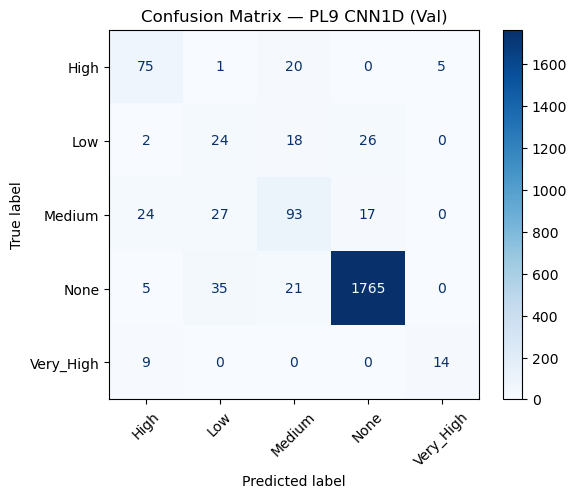

Best epochs: 17
Epoch 1/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7683 - loss: 0.5850
Epoch 2/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8105 - loss: 0.4497
Epoch 3/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8322 - loss: 0.4074
Epoch 4/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8496 - loss: 0.3653
Epoch 5/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8620 - loss: 0.3350
Epoch 6/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8727 - loss: 0.3061
Epoch 7/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8850 - loss: 0.2815
Epoch 8/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8936 - loss: 0.2590
Epoch 9/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9031 - loss: 0.2423
Epoch 10/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9051 - loss: 0.2257
Epoch 11/17
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9139 - loss: 0.2121
Epoch 12/17
172/172 ━━━━━━━━━━━━━━━━

In [33]:
######################### MODELO 10 — CNN 1D para Time Series (janelas) ######################


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

N_CLASSES = len(le_full.classes_)
N_FEATURES = X_all.shape[1]


def make_windows(X, y, W=24, step=1):
    Xw, yw = [], []
    for i in range(W - 1, len(X), step):
        Xw.append(X[i - W + 1 : i + 1])
        yw.append(y[i])
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int32)

W = 24  # 24 horas (1 dia)
Xtr_w, ytr_w = make_windows(X_train, y_train_full, W=W, step=1)
Xva_w, yva_w = make_windows(X_val,   y_val_full,   W=W, step=1)

print("Xtr_w:", Xtr_w.shape, "ytr_w:", ytr_w.shape)
print("Xva_w:", Xva_w.shape, "yva_w:", yva_w.shape)

# ------------------------------------------------------------
# 2) Modelo Conv1D (PL9: Convolução + Pooling)
# ------------------------------------------------------------
def build_cnn1d(W, n_features, n_classes):
    inp = keras.Input(shape=(W, n_features), name="window_input")

    x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name=f"cnn1d_W{W}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_cnn1d = build_cnn1d(W, N_FEATURES, N_CLASSES)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

hist_cnn = model_cnn1d.fit(
    Xtr_w, ytr_w,
    validation_data=(Xva_w, yva_w),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# 3) Avaliação (validação)
# ------------------------------------------------------------
yva_pred = model_cnn1d.predict(Xva_w, verbose=0).argmax(axis=1)

print("\n=== PL9 — CNN1D (Val) ===")
print(classification_report(yva_w, yva_pred, target_names=le_full.classes_))

cm = confusion_matrix(yva_w, yva_pred)
ConfusionMatrixDisplay(cm, display_labels=le_full.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — PL9 CNN1D (Val)")
plt.show()

best_epochs = len(hist_cnn.history["loss"])
print("Best epochs:", best_epochs)

# ------------------------------------------------------------
# 4) Treino FINAL em TODO o treino (X_all, y_full)
# ------------------------------------------------------------
Xall_w, yall_w = make_windows(X_all, y_full, W=W, step=1)

model_cnn1d_final = build_cnn1d(W, N_FEATURES, N_CLASSES)
model_cnn1d_final.fit(
    Xall_w, yall_w,
    epochs=best_epochs,
    batch_size=64,
    verbose=1
)

# ------------------------------------------------------------
# 5) Prever TESTE + Submissão
# ------------------------------------------------------------
Xtest_w, _ = make_windows(X_test, np.zeros(len(X_test), dtype=np.int32), W=W, step=1)

y_test_pred = model_cnn1d_final.predict(Xtest_w, verbose=0).argmax(axis=1)
labels_pred = le_full.inverse_transform(y_test_pred)

dummy = pd.read_csv("dummy_submission.csv")

pad_label = "None" if "None" in le_full.classes_ else le_full.classes_[0]
pad = np.array([pad_label] * (W - 1), dtype=object)

labels_full = np.concatenate([pad, labels_pred])

assert len(dummy) == len(labels_full), f"dummy={len(dummy)} vs pred={len(labels_full)}"

dummy["Result"] = labels_full
dummy.to_csv("submission_10_cnn1d.csv", index=False)

print("Submissão pronta: submission_10_cnn1d.csv")


capta bem picos (High/Very_High) e não destrói o None.
problema está em Low e Medium:
Low (linha “Low”): muita coisa vai para None (33) e Medium (24)
Medium: também escorrega muito para High (32) e None (29)

Train windows: (8789, 24, 91) (8789,)
Val windows  : (2181, 24, 91) (2181,)
Epoch 1/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7440 - loss: 0.6312 - val_accuracy: 0.8684 - val_loss: 0.3521 - learning_rate: 5.0000e-04
Epoch 2/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7971 - loss: 0.4859 - val_accuracy: 0.8757 - val_loss: 0.3210 - learning_rate: 5.0000e-04
Epoch 3/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8211 - loss: 0.4363 - val_accuracy: 0.8794 - val_loss: 0.2947 - learning_rate: 5.0000e-04
Epoch 4/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8354 - loss: 0.3958 - val_accuracy: 0.8904 - val_loss: 0.2752 - learning_rate: 5.0000e-04
Epoch 5/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8516 - loss: 0.3550 - val_accuracy: 0.8973 - val_loss: 0.2588 - learning_rate: 5.0000e-04
Epoch 6/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8647 - loss: 0.3268 - val_accuracy: 0.9019 - val_loss: 0.2501 - learning

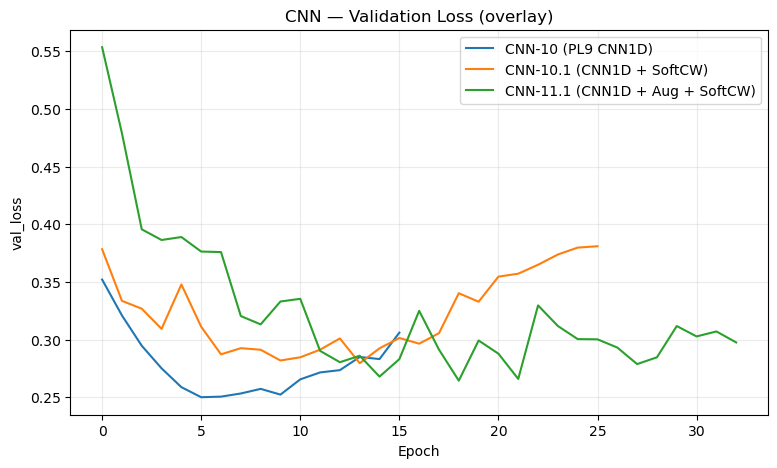

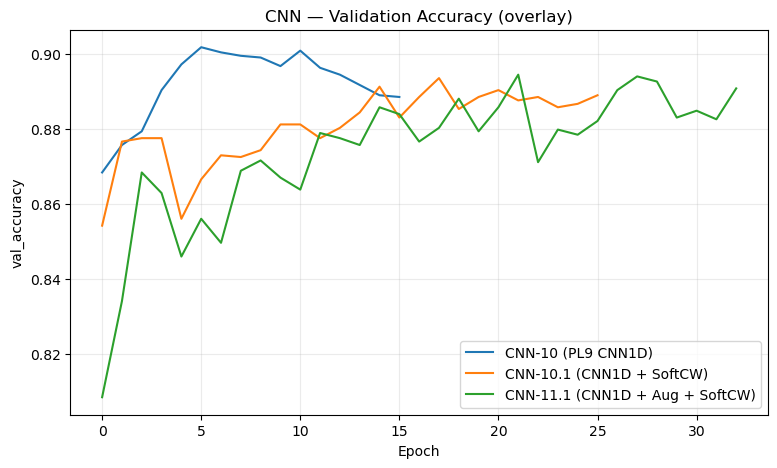

✅ Guardado: cnn_metrics_summary.csv

Resumo CNN (ordenado por f1_macro ):
                             model  accuracy  f1_macro  f1_weighted  \
0               CNN-10 (PL9 CNN1D)  0.901880  0.632451     0.896819   
1  CNN-11.1 (CNN1D + Aug + SoftCW)  0.888125  0.602597     0.890290   
2        CNN-10.1 (CNN1D + SoftCW)  0.884457  0.601392     0.892061   

   precision_macro  recall_macro  val_loss_min  epoch_best_val_loss  \
0         0.679214      0.611968      0.250131                    6   
1         0.570483      0.662017      0.264501                   19   
2         0.612138      0.618306      0.279610                   14   

   val_acc_best  epoch_best_val_acc  
0      0.901880                   6  
1      0.894544                  22  
2      0.893627                  18  

🏆 Melhor CNN (por f1_macro): CNN-10 (PL9 CNN1D)
model                  CNN-10 (PL9 CNN1D)
accuracy                          0.90188
f1_macro                         0.632451
f1_weighted                  

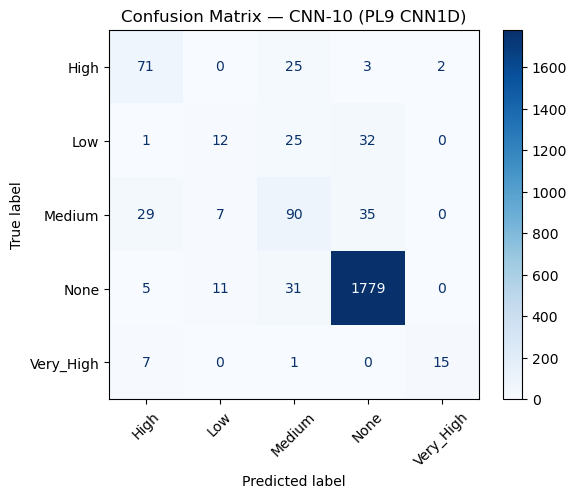


CNN-10 (PL9 CNN1D) — VAL report
              precision    recall  f1-score   support

        High       0.63      0.70      0.66       101
         Low       0.40      0.17      0.24        70
      Medium       0.52      0.56      0.54       161
        None       0.96      0.97      0.97      1826
   Very_High       0.88      0.65      0.75        23

    accuracy                           0.90      2181
   macro avg       0.68      0.61      0.63      2181
weighted avg       0.90      0.90      0.90      2181



In [35]:
# ============================================================
# CNNs (10 / 10.1 / 11.1) — treino + métricas + overlays
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# -------------------------
# SEED
# -------------------------
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# -------------------------
# CONFIG
# -------------------------
W = 24
STEP = 1
BATCH = 64

N_CLASSES = len(le_full.classes_)
N_FEATURES = X_all.shape[1]

# ============================================================
# 0) WINDOWS
# ============================================================
def make_windows(X, y=None, W=24, step=1):
    X = np.asarray(X, dtype=np.float32)
    N = len(X)
    Xw, yw = [], [] if y is not None else None

    for end in range(W - 1, N, step):
        start = end - W + 1
        Xw.append(X[start:end+1])
        if y is not None:
            yw.append(int(y[end]))

    Xw = np.array(Xw, dtype=np.float32)
    if y is not None:
        yw = np.array(yw, dtype=np.int32)
    return Xw, yw

Xtr_w, ytr_w = make_windows(X_train, y_train_full, W=W, step=STEP)
Xva_w, yva_w = make_windows(X_val,   y_val_full,   W=W, step=STEP)

print("Train windows:", Xtr_w.shape, ytr_w.shape)
print("Val windows  :", Xva_w.shape, yva_w.shape)

# ============================================================
# 1) REGISTO GLOBAL (para garantir que tudo "responde")
# ============================================================
CNN_RUNS = {}  # name -> dict(history, y_true, y_pred, metrics)

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    }

def register_run(name, history, y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    m = compute_metrics(y_true, y_pred)

    # métricas do history (val_loss min / val_acc max)
    h = history.history
    if "val_loss" in h:
        m["val_loss_min"] = float(np.min(h["val_loss"]))
        m["epoch_best_val_loss"] = int(np.argmin(h["val_loss"]) + 1)
    if "val_accuracy" in h:
        m["val_acc_best"] = float(np.max(h["val_accuracy"]))
        m["epoch_best_val_acc"] = int(np.argmax(h["val_accuracy"]) + 1)

    CNN_RUNS[name] = {
        "history": history,
        "y_true": y_true,
        "y_pred": y_pred,
        "metrics": m
    }
    print(f"✅ Registado: {name} | acc={m['accuracy']:.4f} | macroF1={m['f1_macro']:.4f}")

def plot_overlays(save_dir=None, prefix="cnn"):
    # VAL LOSS overlay
    plt.figure(figsize=(9,5))
    ok = False
    for name, run in CNN_RUNS.items():
        h = run["history"].history
        if "val_loss" in h:
            plt.plot(h["val_loss"], label=name)
            ok = True
    if ok:
        plt.title("CNN — Validation Loss (overlay)")
        plt.xlabel("Epoch"); plt.ylabel("val_loss")
        plt.grid(alpha=0.25); plt.legend()
        if save_dir:
            import os
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir}/{prefix}__val_loss_overlay.png", dpi=200, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️ Nenhuma curva val_loss encontrada.")

    # VAL ACC overlay
    plt.figure(figsize=(9,5))
    ok = False
    for name, run in CNN_RUNS.items():
        h = run["history"].history
        if "val_accuracy" in h:
            plt.plot(h["val_accuracy"], label=name)
            ok = True
    if ok:
        plt.title("CNN — Validation Accuracy (overlay)")
        plt.xlabel("Epoch"); plt.ylabel("val_accuracy")
        plt.grid(alpha=0.25); plt.legend()
        if save_dir:
            import os
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir}/{prefix}__val_acc_overlay.png", dpi=200, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️ Nenhuma curva val_accuracy encontrada.")

def export_summary(csv_path="cnn_metrics_summary.csv", sort_by="f1_macro"):
    rows = []
    for name, run in CNN_RUNS.items():
        row = {"model": name}
        row.update(run["metrics"])
        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)
    df.to_csv(csv_path, index=False)
    print(f"✅ Guardado: {csv_path}")
    print("\nResumo CNN (ordenado por", sort_by, "):")
    print(df)
    return df

def plot_cm(name, class_names):
    run = CNN_RUNS[name]
    cm = confusion_matrix(run["y_true"], run["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

# ============================================================
# 2) MODELOS
# ============================================================
def build_cnn10(W, n_features, n_classes):
    inp = keras.Input(shape=(W, n_features), name="window_input")

    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name="CNN10_PL9")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def soft_class_weights_default(le_full):
    # pesos moderados (ajusta se quiseres)
    name_to_w = {
        "None": 0.70,
        "Medium": 1.00,
        "Low": 1.40,
        "High": 1.30,
        "Very_High": 1.60
    }
    cw = {i: 1.0 for i in range(len(le_full.classes_))}
    for name, w in name_to_w.items():
        if name in le_full.classes_:
            idx = int(np.where(le_full.classes_ == name)[0][0])
            cw[idx] = float(w)
    return cw

def build_cnn101(W, n_features, n_classes):
    # igual ao CNN10 (comparação justa)
    return build_cnn10(W, n_features, n_classes)

def build_cnn111(W, n_features, n_classes):
    # arquitetura ligeiramente mais regularizada (boa com augmentation)
    inp = keras.Input(shape=(W, n_features), name="window_input")

    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name="CNN11_1_aug_softcw")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ============================================================
# 3) CALLBACKS
# ============================================================
def make_callbacks(patience_es=10, patience_rlr=5):
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience_es,
        restore_best_weights=True
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=patience_rlr,
        min_lr=1e-5,
        verbose=1
    )
    return [early_stop, reduce_lr]

# ============================================================
# 4) CNN-10 (PL9 CNN1D)
# ============================================================
model10 = build_cnn10(W, N_FEATURES, N_CLASSES)
hist10 = model10.fit(
    Xtr_w, ytr_w,
    validation_data=(Xva_w, yva_w),
    epochs=120,
    batch_size=BATCH,
    callbacks=make_callbacks(patience_es=10, patience_rlr=5),
    verbose=1
)

y_pred10 = model10.predict(Xva_w, verbose=0).argmax(axis=1)
register_run("CNN-10 (PL9 CNN1D)", hist10, yva_w, y_pred10)

# ============================================================
# 5) CNN-10.1 (CNN1D + SoftCW)
# ============================================================
cw_soft = soft_class_weights_default(le_full)
print("Soft class_weight:", {le_full.inverse_transform([k])[0]: v for k, v in cw_soft.items()})

model101 = build_cnn101(W, N_FEATURES, N_CLASSES)
hist101 = model101.fit(
    Xtr_w, ytr_w,
    validation_data=(Xva_w, yva_w),
    epochs=160,
    batch_size=BATCH,
    callbacks=make_callbacks(patience_es=12, patience_rlr=5),
    class_weight=cw_soft,
    verbose=1
)

y_pred101 = model101.predict(Xva_w, verbose=0).argmax(axis=1)
register_run("CNN-10.1 (CNN1D + SoftCW)", hist101, yva_w, y_pred101)

# ============================================================
# 6) CNN-11.1 (CNN1D + Aug + SoftCW)
# ============================================================
def augment_batch(x, y, noise_std=0.005, scale_std=0.01):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=noise_std, dtype=x.dtype)
    scale = tf.random.normal((tf.shape(x)[0], 1, 1), mean=1.0, stddev=scale_std, dtype=x.dtype)
    x_aug = (x + noise) * scale
    return x_aug, y

ds_train = tf.data.Dataset.from_tensor_slices((Xtr_w, ytr_w))
ds_train = ds_train.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
ds_train = ds_train.batch(BATCH).map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((Xva_w, yva_w))
ds_val = ds_val.batch(BATCH).prefetch(tf.data.AUTOTUNE)

model111 = build_cnn111(W, N_FEATURES, N_CLASSES)
hist111 = model111.fit(
    ds_train,
    validation_data=ds_val,
    epochs=200,
    callbacks=make_callbacks(patience_es=14, patience_rlr=5),
    class_weight=cw_soft,
    verbose=1
)

y_pred111 = model111.predict(Xva_w, verbose=0).argmax(axis=1)
register_run("CNN-11.1 (CNN1D + Aug + SoftCW)", hist111, yva_w, y_pred111)

# ============================================================
# 7) OVERLAYS + CSV + (opcional) CM do melhor
# ============================================================
plot_overlays(save_dir="figs_cnn", prefix="cnn")

df_cnn = export_summary("cnn_metrics_summary.csv", sort_by="f1_macro")

best_name = df_cnn.loc[0, "model"]
print("\n🏆 Melhor CNN (por f1_macro):", best_name)
print(df_cnn.loc[0])

# matriz de confusão do melhor (opcional)
plot_cm(best_name, class_names=list(le_full.classes_))

# relatório detalhado do melhor (opcional)
print("\n" + best_name + " — VAL report")
print(classification_report(CNN_RUNS[best_name]["y_true"], CNN_RUNS[best_name]["y_pred"],
                            target_names=list(le_full.classes_), zero_division=0))


In [37]:
######################## MODELO 12 - LSTM E GRU ##################
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# -------------------------
# CONFIG
# -------------------------
WINDOW = 24
STEP = 1
BATCH = 64
EPOCHS = 120

N_CLASSES = len(le_full.classes_)
N_FEATURES = X_all.shape[1]

# Soft weights (ajusta como no teu Modelo 6.2)
SOFT_CLASS_WEIGHT = {
    "High": 1.2,
    "Low": 1.35,
    "Medium": 1.0,
    "None": 0.85,
    "Very_High": 1.45
}

# converte weights por label -> weights por índice (Keras usa índice)
class_weight = {int(le_full.transform([k])[0]): v for k, v in SOFT_CLASS_WEIGHT.items()}

# -------------------------
# WINDOWS COM PADDING À ESQUERDA
# (garante 1 janela por linha original)
# -------------------------
def make_windows_pad_left(X, y=None, window=24, step=1):
    X = np.asarray(X, dtype=np.float32)
    N, F = X.shape

    pad = np.repeat(X[[0]], repeats=window-1, axis=0)
    Xp = np.vstack([pad, X])

    Xw = []
    yw = [] if y is not None else None

    for t in range(0, N, step):
        end = t + (window - 1)
        start = end - window + 1
        Xw.append(Xp[start:end+1])
        if y is not None:
            yw.append(int(y[t]))

    Xw = np.array(Xw, dtype=np.float32)
    if y is not None:
        yw = np.array(yw, dtype=np.int32)
    return Xw, yw

# -------------------------
# SPLIT TEMPORAL 80/20 EM ALL
# -------------------------
X_seq, y_seq = make_windows_pad_left(X_all, y_full, window=WINDOW, step=STEP)

n = len(X_seq)
cut = int(n * 0.80)
X_train_seq, X_val_seq = X_seq[:cut], X_seq[cut:]
y_train_seq, y_val_seq = y_seq[:cut], y_seq[cut:]

# -------------------------
# MODELOS
# -------------------------
def build_lstm(window, n_features, n_classes, lr=5e-4):
    inp = keras.Input(shape=(window, n_features))
    x = layers.LSTM(96, return_sequences=True)(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name=f"LSTM_W{window}")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_gru(window, n_features, n_classes, lr=5e-4):
    inp = keras.Input(shape=(window, n_features))
    x = layers.GRU(96, return_sequences=True)(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.GRU(64)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name=f"GRU_W{window}")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -------------------------
# TREINO + best_epochs correto
# -------------------------
def fit_temporal(model, use_class_weight=True):
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    ]

    hist = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS,
        batch_size=BATCH,
        shuffle=False,
        callbacks=callbacks,
        class_weight=(class_weight if use_class_weight else None),
        verbose=1
    )

    # avaliação
    yva_pred = model.predict(X_val_seq, verbose=0).argmax(axis=1)
    print("\nVAL acc:", accuracy_score(y_val_seq, yva_pred))
    print("VAL macroF1:", f1_score(y_val_seq, yva_pred, average="macro"))
    print("\nReport:\n", classification_report(y_val_seq, yva_pred, target_names=[str(c) for c in le_full.classes_]))
    print("\nCM:\n", confusion_matrix(y_val_seq, yva_pred))

    best_epochs = int(np.argmin(hist.history["val_loss"]) + 1)
    print("\nBest epochs (argmin val_loss):", best_epochs)
    return best_epochs

# -------------------------
# TREINO FINAL + SUBMISSÃO
# -------------------------
def train_final_and_submit(build_fn, best_epochs, out_csv, lr=5e-4, use_class_weight=True):
    X_all_seq, y_all_seq = make_windows_pad_left(X_all, y_full, window=WINDOW, step=STEP)

    model_final = build_fn(WINDOW, N_FEATURES, N_CLASSES, lr=lr)
    model_final.fit(
        X_all_seq, y_all_seq,
        epochs=best_epochs,
        batch_size=BATCH,
        shuffle=False,
        class_weight=(class_weight if use_class_weight else None),
        verbose=1
    )

    X_test_seq, _ = make_windows_pad_left(X_test, y=None, window=WINDOW, step=STEP)
    y_test_pred = model_final.predict(X_test_seq, verbose=0).argmax(axis=1)
    labels_pred = le_full.inverse_transform(y_test_pred)

    dummy = pd.read_csv("dummy_submission.csv")
    assert len(dummy) == len(labels_pred), f"dummy={len(dummy)} vs pred={len(labels_pred)}"
    dummy["Result"] = labels_pred
    dummy.to_csv(out_csv, index=False)
    print("Submissão pronta:", out_csv)

# =========================
# 1) LSTM TEMPORAL (recomendado)
# =========================
model_lstm = build_lstm(WINDOW, N_FEATURES, N_CLASSES, lr=5e-4)
best_lstm = fit_temporal(model_lstm, use_class_weight=True)
train_final_and_submit(build_lstm, best_lstm, "submission_lstm_W24_softcw.csv", lr=5e-4, use_class_weight=True)

# =========================
# 2) GRU TEMPORAL (alternativa)
# =========================
model_gru = build_gru(WINDOW, N_FEATURES, N_CLASSES, lr=5e-4)
best_gru = fit_temporal(model_gru, use_class_weight=True)
train_final_and_submit(build_gru, best_gru, "submission_gru_W24_softcw.csv", lr=5e-4, use_class_weight=True)


Epoch 1/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7155 - loss: 0.8188 - val_accuracy: 0.6869 - val_loss: 0.8072 - learning_rate: 5.0000e-04
Epoch 2/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7629 - loss: 0.6426 - val_accuracy: 0.6765 - val_loss: 0.8099 - learning_rate: 5.0000e-04
Epoch 3/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7777 - loss: 0.6034 - val_accuracy: 0.6824 - val_loss: 0.7635 - learning_rate: 5.0000e-04
Epoch 4/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7730 - loss: 0.6102 - val_accuracy: 0.7645 - val_loss: 0.5571 - learning_rate: 5.0000e-04
Epoch 5/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7783 - loss: 0.5937 - val_accuracy: 0.8603 - val_loss: 0.3758 - learning_rate: 5.0000e-04
Epoch 6/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7931 - loss: 0.5611 - val_accuracy: 0.8702 - val_loss: 0.3461 - learning_rate: 5.0000e-04
Epoch 7/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/ste

Soft class weights podem não estar calibradas para GRU
funcionam bem num modelo, pior noutro
Learning rate e schedule
ele só baixa lr no epoch 12; muitas vezes o GRU beneficia de começar já em 3e-4 ou 2e-4
Arquitetura curta
GRU simples pode perder para CNN1D/Transformer 

Epoch 1/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7214 - loss: 0.8373 - val_accuracy: 0.6951 - val_loss: 0.8242 - learning_rate: 5.0000e-04
Epoch 2/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7650 - loss: 0.6447 - val_accuracy: 0.7064 - val_loss: 0.7015 - learning_rate: 5.0000e-04
Epoch 3/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7763 - loss: 0.6023 - val_accuracy: 0.7722 - val_loss: 0.5238 - learning_rate: 5.0000e-04
Epoch 4/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7726 - loss: 0.6057 - val_accuracy: 0.7731 - val_loss: 0.5161 - learning_rate: 5.0000e-04
Epoch 5/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7836 - loss: 0.5765 - val_accuracy: 0.8058 - val_loss: 0.4693 - learning_rate: 5.0000e-04
Epoch 6/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7862 - loss: 0.5680 - val_accuracy: 0.8730 - val_loss: 0.3535 - learning_rate: 5.0000e-04
Epoch 7/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/ste

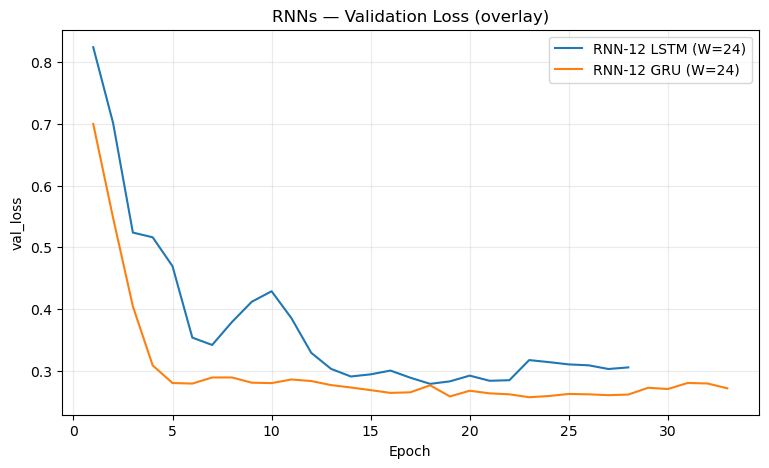

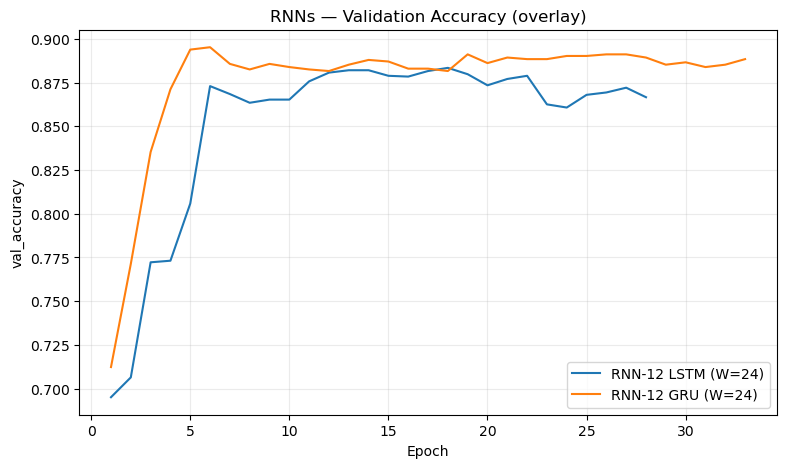


Resumo RNN (ordenado por f1_macro):
                model  accuracy  f1_macro  f1_weighted  precision_macro  \
0   RNN-12 GRU (W=24)  0.888385  0.655686     0.898304         0.638394   
1  RNN-12 LSTM (W=24)  0.883394  0.610141     0.890057         0.594126   

   recall_macro  val_loss_min  epoch_best_val_loss  val_acc_best  \
0       0.69003      0.256816                   23      0.895191   
1       0.63064      0.278481                   18      0.883394   

   epoch_best_val_acc  
0                   6  
1                  18  
✅ Guardado: rnn_metrics_summary.csv

RNN-12 LSTM — VAL
              precision    recall  f1-score   support

        High       0.57      0.68      0.62       105
         Low       0.24      0.31      0.27        71
      Medium       0.50      0.56      0.53       163
        None       0.98      0.95      0.96      1839
   Very_High       0.68      0.65      0.67        26

    accuracy                           0.88      2204
   macro avg       0.59  

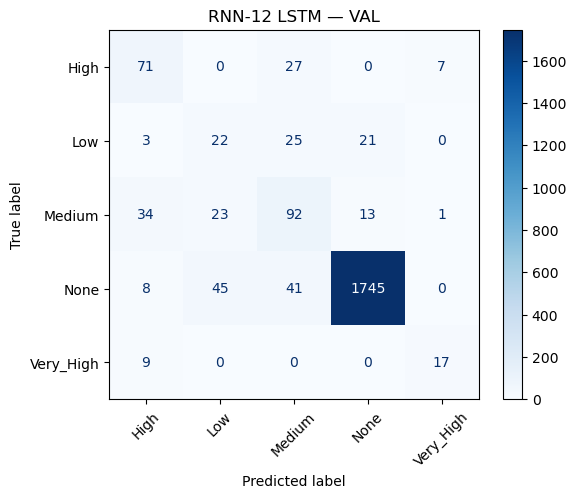


RNN-12 GRU — VAL
              precision    recall  f1-score   support

        High       0.64      0.70      0.67       105
         Low       0.25      0.49      0.33        71
      Medium       0.58      0.55      0.56       163
        None       0.98      0.95      0.97      1839
   Very_High       0.74      0.77      0.75        26

    accuracy                           0.89      2204
   macro avg       0.64      0.69      0.66      2204
weighted avg       0.91      0.89      0.90      2204



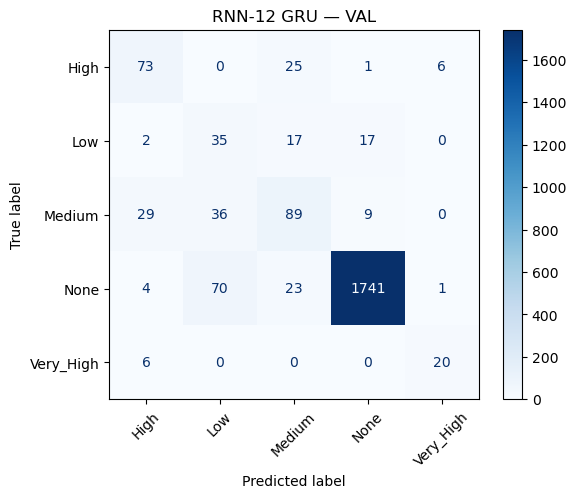


🏆 Melhor RNN (por f1_macro): RNN-12 GRU (W=24)
model                  RNN-12 GRU (W=24)
accuracy                        0.888385
f1_macro                        0.655686
f1_weighted                     0.898304
precision_macro                 0.638394
recall_macro                     0.69003
val_loss_min                    0.256816
epoch_best_val_loss                   23
val_acc_best                    0.895191
epoch_best_val_acc                     6
Name: 0, dtype: object


In [38]:
# ============================================================
# MODELO 12 — LSTM vs GRU
# - Overlays: val_loss + val_accuracy
# - Métricas: accuracy, f1_macro, f1_weighted, precision_macro, recall_macro
# - Confusion Matrix + report (VAL)
# - Guarda CSV: rnn_metrics_summary.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# -------------------------
# 1) HELPERS
# -------------------------
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def best_from_history(hist):
    # hist.history tem listas de loss / acc
    val_loss = np.array(hist.history["val_loss"], dtype=float)
    val_acc  = np.array(hist.history["val_accuracy"], dtype=float)

    best_loss_epoch = int(np.argmin(val_loss) + 1)
    best_acc_epoch  = int(np.argmax(val_acc) + 1)

    return {
        "val_loss_min": float(val_loss.min()),
        "epoch_best_val_loss": best_loss_epoch,
        "val_acc_best": float(val_acc.max()),
        "epoch_best_val_acc": best_acc_epoch
    }

def plot_overlay_histories(histories, metric_key, title, ylab):
    plt.figure(figsize=(9,5))
    for name, hist in histories.items():
        if hist is None:
            continue
        y = hist.history.get(metric_key, None)
        if y is None:
            continue
        plt.plot(range(1, len(y)+1), y, label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylab)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

def show_report_and_cm(y_true, y_pred, label_names, title):
    print("\n" + title)
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

# -------------------------
# 2) FIT que DEVOLVE HIST + PREDS
# (isto substitui o teu fit_temporal atual)
# -------------------------
def fit_temporal_with_outputs(model, X_train_seq, y_train_seq, X_val_seq, y_val_seq,
                              class_weight=None, epochs=120, batch_size=64):

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    ]

    hist = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1
    )

    y_val_pred = model.predict(X_val_seq, verbose=0).argmax(axis=1)

    # best_epochs correto: argmin val_loss
    best_epochs = int(np.argmin(hist.history["val_loss"]) + 1)

    return hist, y_val_pred, best_epochs

# ============================================================
# 3) EXECUÇÃO (AQUI É ONDE TU MUDAS COISAS)
# ============================================================
# REQUISITOS (já existem no teu notebook):
# - X_train_seq, y_train_seq, X_val_seq, y_val_seq
# - build_lstm(), build_gru()
# - le_full.classes_
# - class_weight (dict) (ou None)

# >>>> MUDA APENAS se os teus nomes forem diferentes:
label_names = list(le_full.classes_)

# -------------------------
# 3.1) Treinar LSTM
# -------------------------
model_lstm = build_lstm(WINDOW, N_FEATURES, N_CLASSES, lr=5e-4)
hist_lstm, y_pred_lstm, best_lstm = fit_temporal_with_outputs(
    model_lstm,
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    class_weight=class_weight,
    epochs=EPOCHS,
    batch_size=BATCH
)

print("\nBest epochs LSTM (argmin val_loss):", best_lstm)

# -------------------------
# 3.2) Treinar GRU
# -------------------------
model_gru = build_gru(WINDOW, N_FEATURES, N_CLASSES, lr=5e-4)
hist_gru, y_pred_gru, best_gru = fit_temporal_with_outputs(
    model_gru,
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    class_weight=class_weight,
    epochs=EPOCHS,
    batch_size=BATCH
)

print("\nBest epochs GRU (argmin val_loss):", best_gru)

# ============================================================
# 4) OVERLAYS (val_loss + val_accuracy)
# ============================================================
histories = {
    "RNN-12 LSTM (W=24)": hist_lstm,
    "RNN-12 GRU (W=24)": hist_gru
}

plot_overlay_histories(
    histories,
    metric_key="val_loss",
    title="RNNs — Validation Loss (overlay)",
    ylab="val_loss"
)

plot_overlay_histories(
    histories,
    metric_key="val_accuracy",
    title="RNNs — Validation Accuracy (overlay)",
    ylab="val_accuracy"
)

# ============================================================
# 5) MÉTRICAS + CSV
# ============================================================
rows = []

# ---- LSTM row
row_lstm = {"model": "RNN-12 LSTM (W=24)"}
row_lstm.update(compute_metrics(y_val_seq, y_pred_lstm))
row_lstm.update(best_from_history(hist_lstm))
rows.append(row_lstm)

# ---- GRU row
row_gru = {"model": "RNN-12 GRU (W=24)"}
row_gru.update(compute_metrics(y_val_seq, y_pred_gru))
row_gru.update(best_from_history(hist_gru))
rows.append(row_gru)

df_rnn = pd.DataFrame(rows).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

print("\nResumo RNN (ordenado por f1_macro):")
print(df_rnn)

df_rnn.to_csv("rnn_metrics_summary.csv", index=False)
print("✅ Guardado: rnn_metrics_summary.csv")

# ============================================================
# 6) REPORT + CONFUSION MATRIX (VAL)
# ============================================================
show_report_and_cm(y_val_seq, y_pred_lstm, label_names, "RNN-12 LSTM — VAL")
show_report_and_cm(y_val_seq, y_pred_gru,  label_names, "RNN-12 GRU — VAL")

# ============================================================
# 7) MELHOR MODELO RNN
# ============================================================
best_row = df_rnn.iloc[0]
print("\n🏆 Melhor RNN (por f1_macro):", best_row["model"])
print(best_row)


In [7]:
############################### MODELO 14 - TRANSFORMERS ################################

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

WINDOW = 24
STEP = 1
BATCH = 64
EPOCHS = 120

N_CLASSES = len(le_full.classes_)
N_FEATURES = X_all.shape[1]
D_MODEL = 64
N_HEADS = 4
FF_DIM = 128
DROPOUT = 0.1

def make_windows_pad_left(X, y=None, window=24, step=1):
    X = np.asarray(X, dtype=np.float32)
    N, F = X.shape

    pad = np.repeat(X[[0]], repeats=window-1, axis=0)
    Xp = np.vstack([pad, X])  # (N+window-1, F)

    Xw = []
    yw = [] if y is not None else None

    for t in range(0, N, step):     # dá exatamente N janelas (1 por linha)
        end = t + (window - 1)
        start = end - window + 1
        Xw.append(Xp[start:end+1])
        if y is not None:
            yw.append(int(y[t]))

    Xw = np.array(Xw, dtype=np.float32)
    if y is not None:
        yw = np.array(yw, dtype=np.int32)
    return Xw, yw

# ====== dados com janelas temporais ======
X_seq, y_seq = make_windows_pad_left(X_all, y_full, window=WINDOW, step=STEP)

cut = int(len(X_seq) * 0.80)
X_train_seq, X_val_seq = X_seq[:cut], X_seq[cut:]
y_train_seq, y_val_seq = y_seq[:cut], y_seq[cut:]

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, rate=0.1):
        super().__init__()
        # key_dim é por cabeça; aqui usamos d_model//num_heads
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer():
    inputs = keras.Input(shape=(WINDOW, N_FEATURES))

    # projeção para d_model
    x = layers.Dense(D_MODEL)(inputs)

    # (opcional mas recomendado) positional encoding simples (learnable)
    pos_emb = layers.Embedding(input_dim=WINDOW, output_dim=D_MODEL)
    positions = tf.range(start=0, limit=WINDOW, delta=1)
    x = x + pos_emb(positions)

    x = TransformerBlock(D_MODEL, N_HEADS, FF_DIM, rate=DROPOUT)(x)
    x = TransformerBlock(D_MODEL, N_HEADS, FF_DIM, rate=DROPOUT)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"transformer_W{WINDOW}")
    model.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_transformer()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
]

hist = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

y_val_pred = model.predict(X_val_seq, verbose=0).argmax(axis=1)
print("\nTRANSFORMER TEMPORAL — VAL accuracy:", accuracy_score(y_val_seq, y_val_pred))
print("TRANSFORMER TEMPORAL — VAL macroF1:", f1_score(y_val_seq, y_val_pred, average="macro"))
print("\nReport:\n", classification_report(y_val_seq, y_val_pred, target_names=[str(c) for c in le_full.classes_]))
print("\nConfusion matrix:\n", confusion_matrix(y_val_seq, y_val_pred))

best_epochs = int(np.argmin(hist.history["val_loss"]) + 1)
print("\nBest epochs:", best_epochs)

# treino final
X_all_seq, y_all_seq = make_windows_pad_left(X_all, y_full, window=WINDOW, step=STEP)
model_final = build_transformer()
model_final.fit(X_all_seq, y_all_seq, epochs=best_epochs, batch_size=BATCH, shuffle=False, verbose=1)

# submissão (len == len(X_test))
X_test_seq, _ = make_windows_pad_left(X_test, y=None, window=WINDOW, step=STEP)
y_test_pred = model_final.predict(X_test_seq, verbose=0).argmax(axis=1)
labels_pred = le_full.inverse_transform(y_test_pred)

dummy = pd.read_csv("dummy_submission.csv")
assert len(dummy) == len(labels_pred)
dummy["Result"] = labels_pred
dummy.to_csv("submission_14_transformer_W24.csv", index=False)
print("Submissão pronta: submission_14_transformer_W24.csv")


Epoch 1/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6596 - loss: 1.1123 - val_accuracy: 0.8344 - val_loss: 0.7771 - learning_rate: 5.0000e-04
Epoch 2/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6739 - loss: 1.0639 - val_accuracy: 0.8344 - val_loss: 0.7726 - learning_rate: 5.0000e-04
Epoch 3/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6740 - loss: 1.0572 - val_accuracy: 0.8344 - val_loss: 0.7774 - learning_rate: 5.0000e-04
Epoch 4/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6739 - loss: 1.0477 - val_accuracy: 0.8344 - val_loss: 0.7375 - learning_rate: 5.0000e-04
Epoch 5/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6739 - loss: 1.0417 - val_accuracy: 0.8344 - val_loss: 0.7056 - learning_rate: 5.0000e-04
Epoch 6/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6740 - loss: 1.0393 - val_accuracy: 0.8344 - val_loss: 0.6782 - learning_rate: 5.0000e-04
Epoch 7/120
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/ste

✅ Figura guardada em: figs_learning/transformer_W24_learning_curves.png


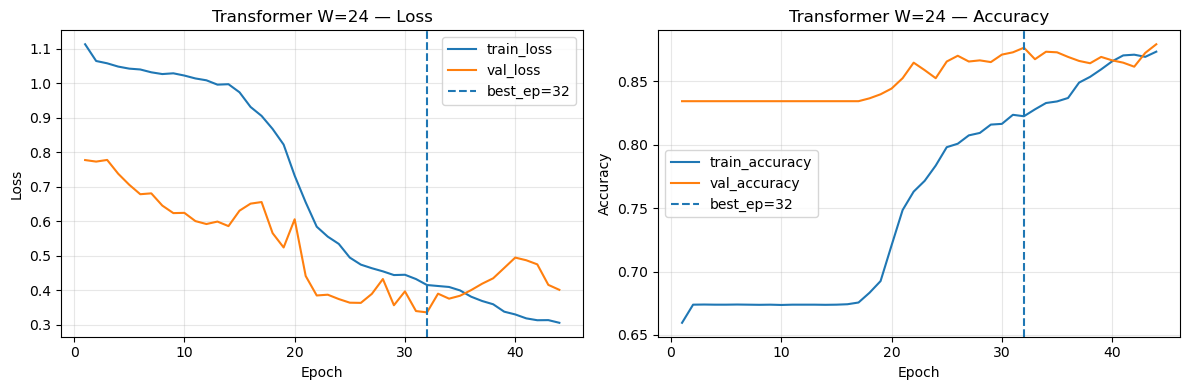

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curves(hist, title="Learning Curves", save_path=None):
    h = hist.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    # best epoch por val_loss (se existir)
    best_ep = None
    if "val_loss" in h:
        best_ep = int(np.argmin(h["val_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # -------- Loss --------
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h["loss"], label="train_loss")
    if "val_loss" in h:
        plt.plot(epochs, h["val_loss"], label="val_loss")
        if best_ep is not None:
            plt.axvline(best_ep, linestyle="--", label=f"best_ep={best_ep}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.grid(alpha=0.3)
    plt.legend()

    # -------- Accuracy --------
    plt.subplot(1, 2, 2)
    if "accuracy" in h:
        plt.plot(epochs, h["accuracy"], label="train_accuracy")
    if "val_accuracy" in h:
        plt.plot(epochs, h["val_accuracy"], label="val_accuracy")
        if best_ep is not None:
            plt.axvline(best_ep, linestyle="--", label=f"best_ep={best_ep}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"✅ Figura guardada em: {save_path}")

    plt.show()

# EXEMPLO de uso:
plot_learning_curves(
    hist,
    title="Transformer W=24",
    save_path="figs_learning/transformer_W24_learning_curves.png"
)


este Transformer temporal W=24, como está, não é melhor do que os  LSTM/GRU/CNN com soft weights. É pior, sobretudo em macro-F1.